# Прогнозирование дождя в Австралии
## Курсовая работа по анализу данных и машинному обучению

## Поиск и выбор набора данных для построения моделей машинного обучения. На основе выбранного набора данных студент должен построить модели машинного обучения для решения или задачи классификации, или задачи регрессии.

### Описание датасета

В качестве набора данных будем использовать датасет **Rain in Australia** (Weather Dataset) с Kaggle.

**Актуальность задачи:** Прогнозирование осадков является важной задачей для сельского хозяйства, транспорта, туризма и повседневной жизни людей. Точный прогноз дождя помогает фермерам планировать посевные работы, водителям выбирать безопасные маршруты, а обычным людям решать, брать ли с собой зонт.

**Источник данных:** Данные собраны с многочисленных метеостанций по всей Австралии за примерно 10-летний период. Источник: Bureau of Meteorology (http://www.bom.gov.au/climate/data).

**Структура датасета:**
- **Date** - дата наблюдения в формате ГГГГ-ММ-ДД
- **Location** - название метеостанции/города
- **MinTemp** - минимальная температура за день (градусы Цельсия)
- **MaxTemp** - максимальная температура за день (градусы Цельсия)
- **Rainfall** - количество осадков за день (мм)
- **Evaporation** - испарение (мм)
- **Sunshine** - продолжительность солнечного сияния (часы)
- **WindGustDir** - направление самого сильного порыва ветра
- **WindGustSpeed** - скорость самого сильного порыва ветра (км/ч)
- **WindDir9am** - направление ветра в 9 утра
- **WindDir3pm** - направление ветра в 3 часа дня
- **WindSpeed9am** - скорость ветра в 9 утра (км/ч)
- **WindSpeed3pm** - скорость ветра в 3 часа дня (км/ч)
- **Humidity9am** - влажность в 9 утра (%)
- **Humidity3pm** - влажность в 3 часа дня (%)
- **Pressure9am** - атмосферное давление в 9 утра (гПа)
- **Pressure3pm** - атмосферное давление в 3 часа дня (гПа)
- **Cloud9am** - облачность в 9 утра (октанты)
- **Cloud3pm** - облачность в 3 часа дня (октанты)
- **Temp9am** - температура в 9 утра (градусы Цельсия)
- **Temp3pm** - температура в 3 часа дня (градусы Цельсия)
- **RainToday** - был ли дождь сегодня (Yes/No)
- **RainTomorrow** - целевой признак. Будет ли дождь завтра (Yes/No).

В рассматриваемом проекте будем решать обе задачи:
- Для решения **задачи классификации** в качестве целевого признака будем использовать "RainTomorrow". Это задача бинарной классификации (Yes/No).
- Для решения **задачи регрессии** в качестве целевого признака будем использовать "Rainfall" (количество осадков в мм).

### Импорт библиотек

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, roc_auc_score
)
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set(style="ticks")
plt.rcParams['figure.figsize'] = (10, 6)
print('Библиотеки успешно импортированы')

Библиотеки успешно импортированы


### Загрузка данных

In [4]:
# Загрузка датасета
# Если файл называется weatherAUS.csv или подобным, укажите правильный путь
df = pd.read_csv('weatherAUS.csv')

# Удалим дубликаты, если они присутствуют
df = df.drop_duplicates()

print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

Размер датасета: (145460, 23)
Колонки: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


## Проведение разведочного анализа данных. Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.

### Первичный просмотр данных

In [5]:
# Первые 10 строк данных
df.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [6]:
# Информация о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
# Статистическое описание числовых признаков
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


### Анализ пропущенных значений

In [8]:
# Проверка наличия пропусков
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Процент пропусков': missing_percent
}).sort_values(by='Процент пропусков', ascending=False)

print("Анализ пропущенных значений:\n")
print(missing_df[missing_df['Количество пропусков'] > 0])
print(f"\nВсего строк: {len(df)}")

Анализ пропущенных значений:

               Количество пропусков  Процент пропусков
Sunshine                      69835          48.009762
Evaporation                   62790          43.166506
Cloud3pm                      59358          40.807095
Cloud9am                      55888          38.421559
Pressure9am                   15065          10.356799
Pressure3pm                   15028          10.331363
WindDir9am                    10566           7.263853
WindGustDir                   10326           7.098859
WindGustSpeed                 10263           7.055548
Humidity3pm                    4507           3.098446
WindDir3pm                     4228           2.906641
Temp3pm                        3609           2.481094
RainTomorrow                   3267           2.245978
Rainfall                       3261           2.241853
RainToday                      3261           2.241853
WindSpeed3pm                   3062           2.105046
Humidity9am                    2654

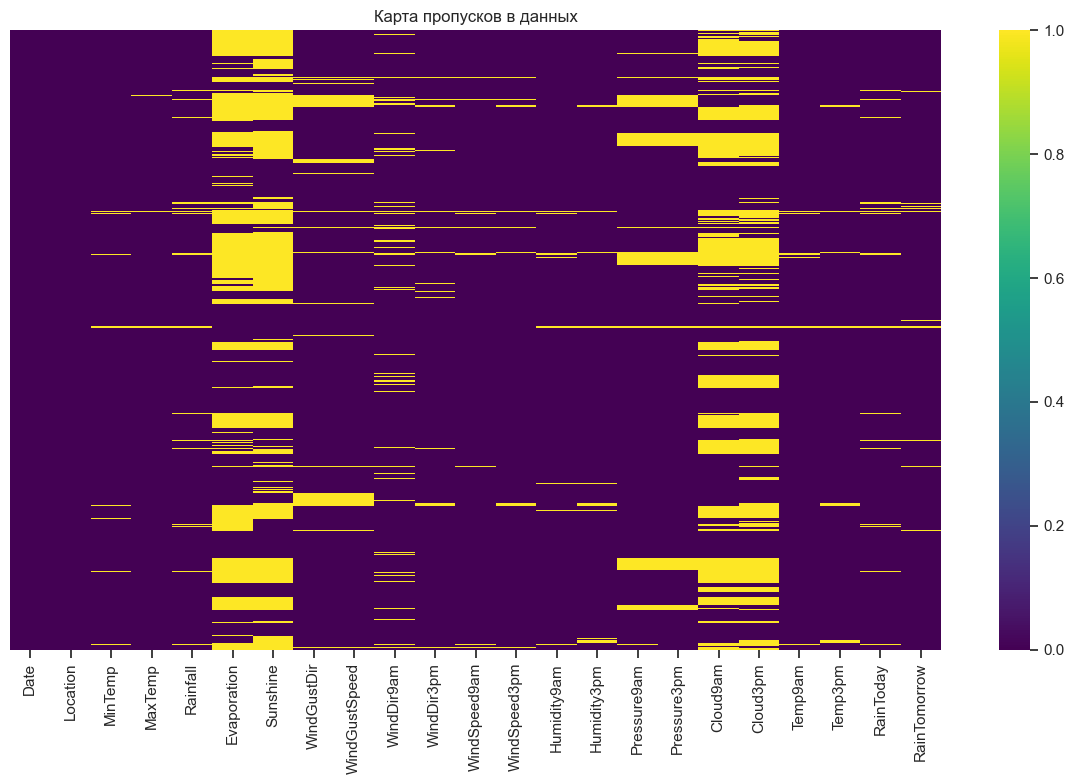

In [9]:
# Визуализация пропусков
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Карта пропусков в данных')
plt.tight_layout()
plt.show()

**Наблюдение:** Датасет содержит значительное количество пропусков, особенно в столбцах Sunshine, Evaporation, Cloud9am, Cloud3pm. Для построения моделей необходимо обработать пропуски.

### Анализ целевого признака классификации (RainTomorrow)

Распределение RainTomorrow:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Проценты:
RainTomorrow
No     77.581878
Yes    22.418122
Name: proportion, dtype: float64


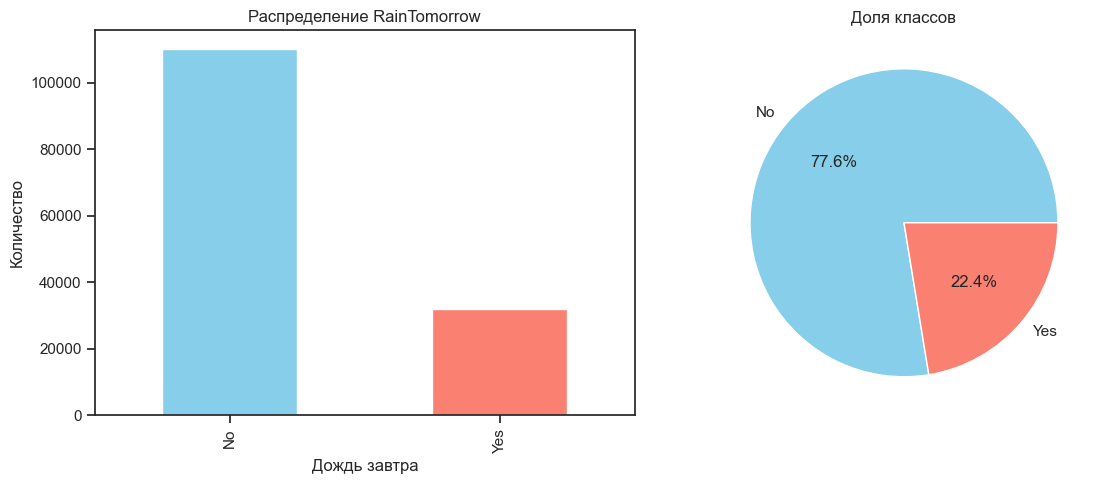

In [11]:
# Анализ целевого признака классификации
print("Распределение RainTomorrow:")
print(df['RainTomorrow'].value_counts())
print(f"\nПроценты:")
print(df['RainTomorrow'].value_counts(normalize=True) * 100)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['RainTomorrow'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Распределение RainTomorrow')
axes[0].set_xlabel('Дождь завтра')
axes[0].set_ylabel('Количество')

df['RainTomorrow'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1].set_title('Доля классов')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Проверка дисбаланса
class_0, class_1 = df['RainTomorrow'].value_counts()

**Вывод:** Присутствует умеренный дисбаланс классов. Это важно учитывать при выборе метрик качества. Будем использовать precision, recall, F1-меру и ROC-AUC.

### Анализ целевого признака регрессии (Rainfall)

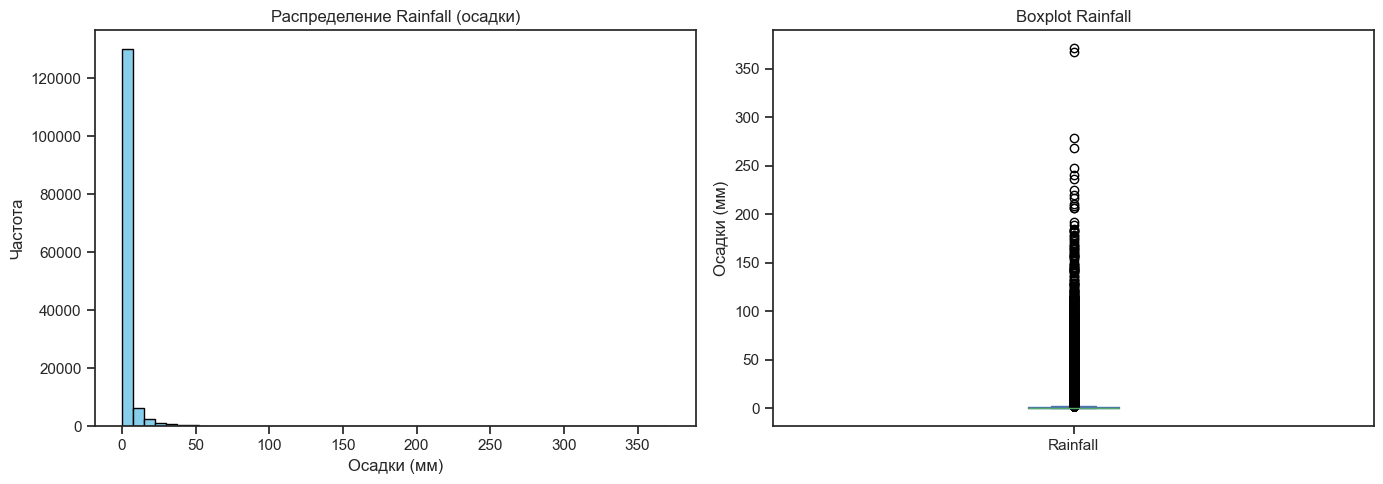

Статистика Rainfall:
Среднее: 2.36
Медиана: 0.00
Максимум: 371.00
Стандартное отклонение: 8.48


In [12]:
# Анализ распределения Rainfall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Rainfall'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Распределение Rainfall (осадки)')
axes[0].set_xlabel('Осадки (мм)')
axes[0].set_ylabel('Частота')

# Исправление: используем boxplot через pandas DataFrame или напрямую через matplotlib
df['Rainfall'].dropna().plot.box(ax=axes[1])
axes[1].set_title('Boxplot Rainfall')
axes[1].set_ylabel('Осадки (мм)')

plt.tight_layout()
plt.show()

print(f"Статистика Rainfall:")
print(f"Среднее: {df['Rainfall'].mean():.2f}")
print(f"Медиана: {df['Rainfall'].median():.2f}")
print(f"Максимум: {df['Rainfall'].max():.2f}")
print(f"Стандартное отклонение: {df['Rainfall'].std():.2f}")

### Визуализация взаимосвязей признаков

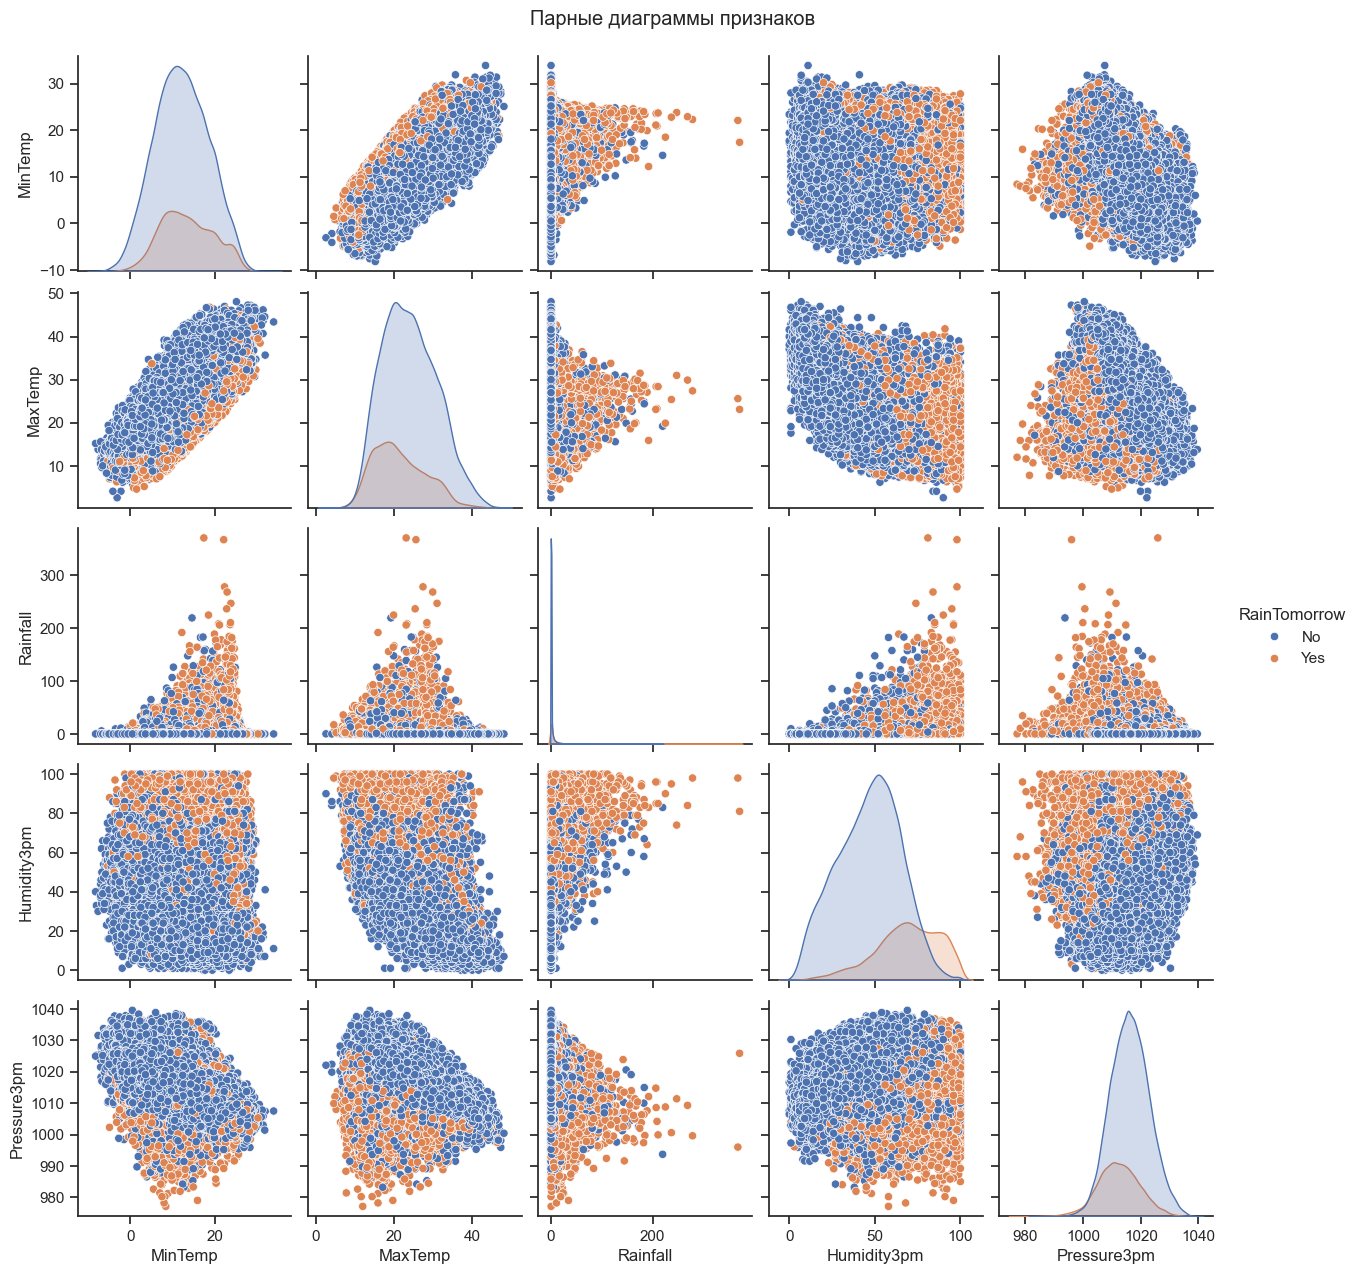

In [13]:
# Выбор числовых колонок для анализа
numeric_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

# Pairplot для небольшого набора признаков (может выполняться долго, поэтому ограничим)
sample_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm', 'Pressure3pm']
sns.pairplot(df[sample_cols + ['RainTomorrow']].dropna(), hue='RainTomorrow')
plt.suptitle('Парные диаграммы признаков', y=1.02)
plt.show()

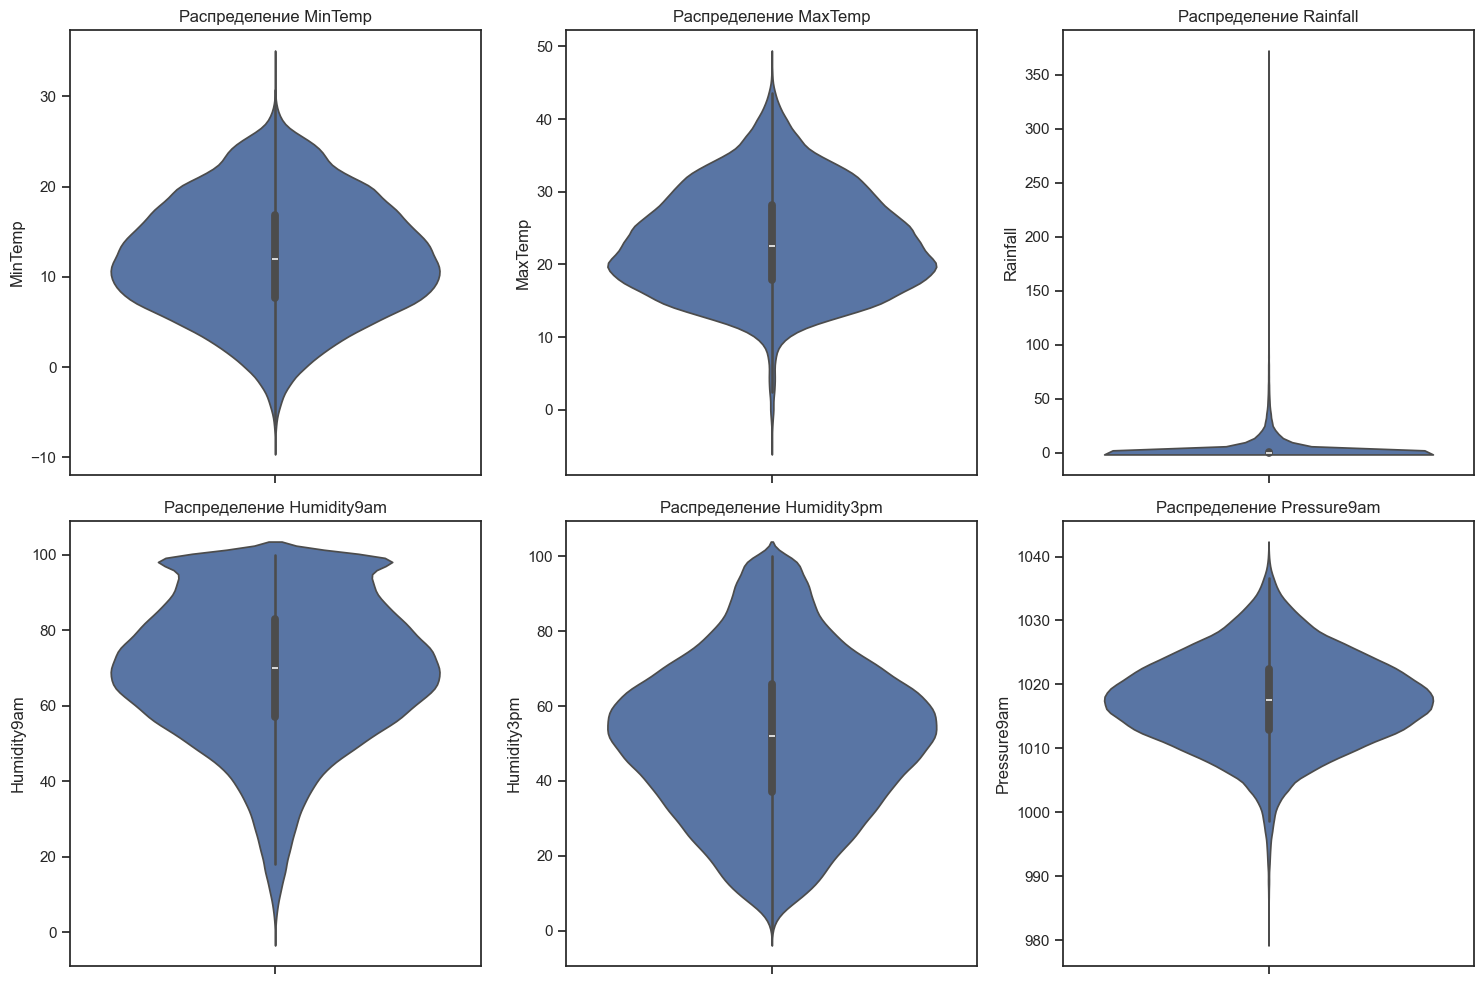

In [14]:
# Скрипичные диаграммы для числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm', 'Pressure9am']):
    sns.violinplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

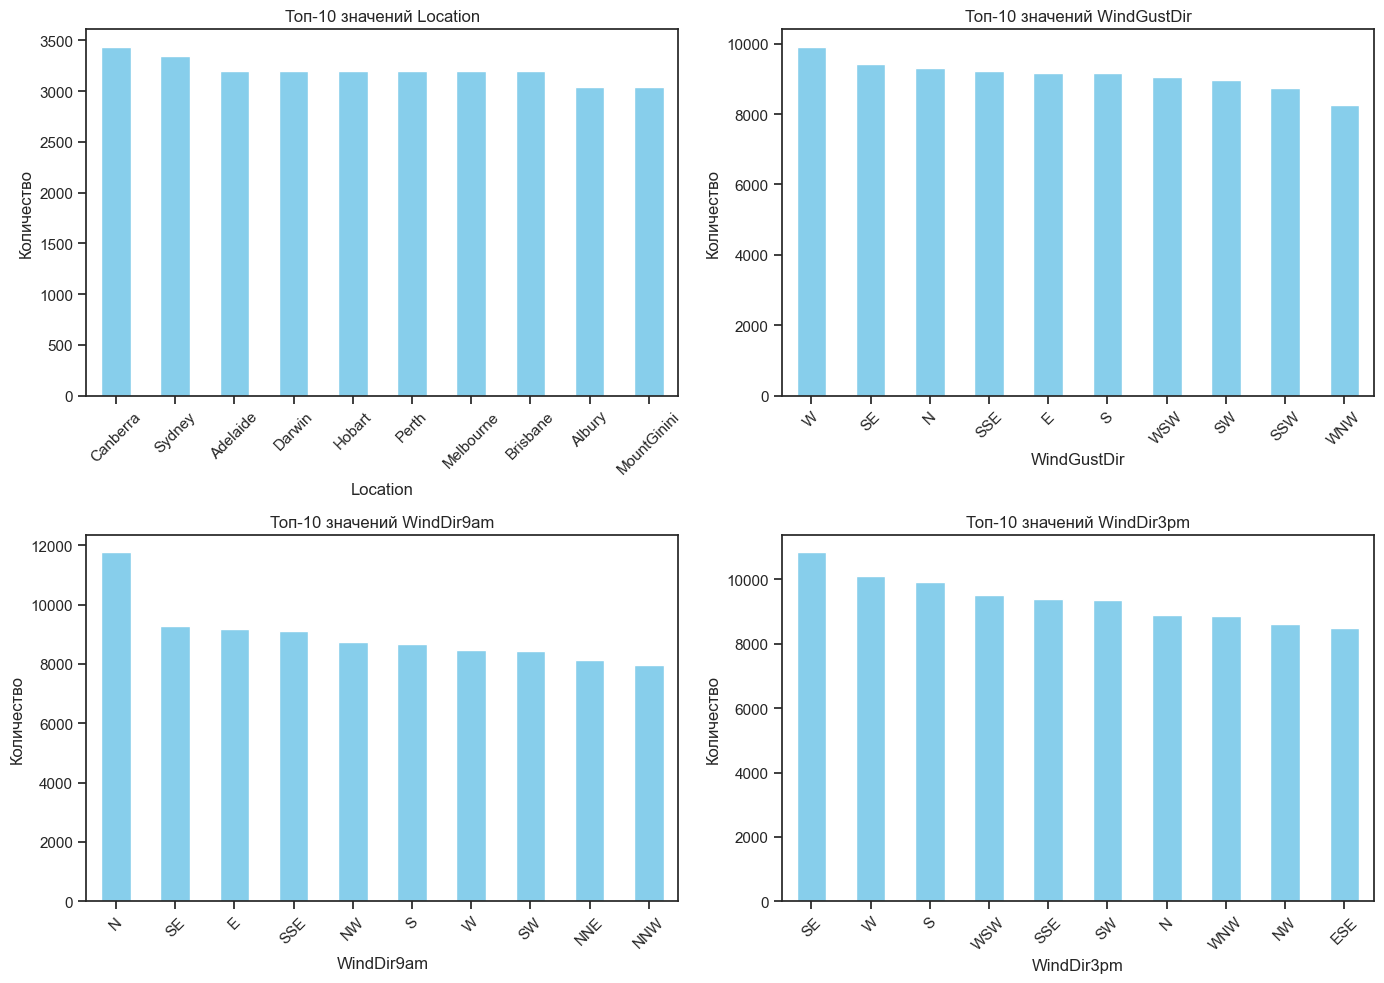

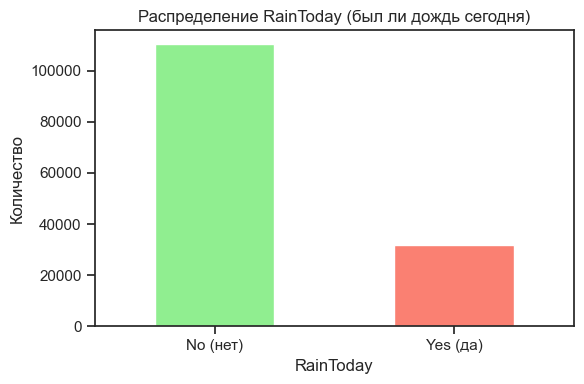

Распределение RainToday:
RainToday
No     110319
Yes     31880
Name: count, dtype: int64

Проценты:
RainToday
No     77.580714
Yes    22.419286
Name: proportion, dtype: float64


In [12]:
# Анализ категориальных признаков
# Признаки с большим количеством уникальных значений
high_cardinality_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
# Бинарный признак
binary_cols = ['RainToday']

# Графики для high-cardinality признаков (топ-10)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(high_cardinality_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Топ-10 значений {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Отдельный график для бинарного признака RainToday
fig, ax = plt.subplots(figsize=(6, 4))
df['RainToday'].value_counts().plot(kind='bar', ax=ax, color=['lightgreen', 'salmon'])
ax.set_title('Распределение RainToday (был ли дождь сегодня)')
ax.set_xlabel('RainToday')
ax.set_ylabel('Количество')
ax.set_xticklabels(['No (нет)', 'Yes (да)'], rotation=0)
plt.tight_layout()
plt.show()

# Дополнительно: выведем проценты для RainToday
print("Распределение RainToday:")
print(df['RainToday'].value_counts())
print(f"\nПроценты:")
print(df['RainToday'].value_counts(normalize=True) * 100)

## Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.

### Предобработка данных

Для построения моделей будем:
1. Удалять признаки с высоким процентом пропусков (>40%)
2. Заполнять пропуски в оставшихся признаках
3. Кодировать категориальные признаки
4. Масштабировать числовые признаки
5. Создавать вспомогательные признаки из даты (месяц, день недели)

In [13]:
# Создаем копию данных для обработки
df_processed = df.copy()

# 1. Удаляем признаки с >40% пропусков
threshold = 40
missing_pct = df_processed.isnull().sum() / len(df_processed) * 100
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"Удаляемые колонки (>40% пропусков): {cols_to_drop}")
df_processed = df_processed.drop(columns=cols_to_drop)

# Также удаляем Date (не используем как признак, но можем извлечь полезную информацию)
if 'Date' in df_processed.columns:
    df_processed['Date'] = pd.to_datetime(df_processed['Date'])
    df_processed['Month'] = df_processed['Date'].dt.month
    df_processed['DayOfWeek'] = df_processed['Date'].dt.dayofweek
    df_processed = df_processed.drop(columns=['Date'])

print(f"\nРазмер после удаления колонок: {df_processed.shape}")
print(f"Колонки: {df_processed.columns.tolist()}")

Удаляемые колонки (>40% пропусков): ['Evaporation', 'Sunshine', 'Cloud3pm']

Размер после удаления колонок: (145460, 21)
Колонки: ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Month', 'DayOfWeek']


In [14]:
# 2. Обработка пропусков в оставшихся колонках
# Для числовых признаков используем медиану
# Для категориальных - моду

# Целевой признак для классификации обрабатываем отдельно
target_col = 'RainTomorrow'

# Признаки для моделирования (исключаем целевой)
feature_cols = [col for col in df_processed.columns if col != target_col]

# Разделяем на числовые и категориальные признаки (без целевого)
numeric_cols_processed = df_processed[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_processed = df_processed[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"Числовые колонки: {numeric_cols_processed}")
print(f"Категориальные колонки (признаки): {categorical_cols_processed}")

# Заполнение пропусков в числовых признаках (БЕЗ inplace=True)
for col in numeric_cols_processed:
    median_val = df_processed[col].median()
    df_processed[col] = df_processed[col].fillna(median_val)

# Заполнение пропусков в категориальных признаках (БЕЗ inplace=True)
for col in categorical_cols_processed:
    mode_val = df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'Unknown'
    df_processed[col] = df_processed[col].fillna(mode_val)

# Отдельно обрабатываем целевой признак RainTomorrow
# Если есть пропуски в целевом признаке - удаляем такие строки
initial_count = len(df_processed)
df_processed = df_processed.dropna(subset=[target_col])
print(f"Удалено строк с пропусками в RainTomorrow: {initial_count - len(df_processed)}")

# Проверка, что пропусков больше нет
print(f"\nПропуски после обработки: {df_processed.isnull().sum().sum()}")

Числовые колонки: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'Month', 'DayOfWeek']
Категориальные колонки (признаки): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
Удалено строк с пропусками в RainTomorrow: 3267

Пропуски после обработки: 0


In [15]:
# 3. Кодирование категориальных признаков
label_encoders = {}

for col in categorical_cols_processed:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Удаляем исходные категориальные колонки (оставляем закодированные)
df_processed = df_processed.drop(columns=categorical_cols_processed)

print(f"\nРазмер после кодирования: {df_processed.shape}")
print(f"Колонки: {df_processed.columns.tolist()}")

Location: {'Adelaide': np.int64(0), 'Albany': np.int64(1), 'Albury': np.int64(2), 'AliceSprings': np.int64(3), 'BadgerysCreek': np.int64(4), 'Ballarat': np.int64(5), 'Bendigo': np.int64(6), 'Brisbane': np.int64(7), 'Cairns': np.int64(8), 'Canberra': np.int64(9), 'Cobar': np.int64(10), 'CoffsHarbour': np.int64(11), 'Dartmoor': np.int64(12), 'Darwin': np.int64(13), 'GoldCoast': np.int64(14), 'Hobart': np.int64(15), 'Katherine': np.int64(16), 'Launceston': np.int64(17), 'Melbourne': np.int64(18), 'MelbourneAirport': np.int64(19), 'Mildura': np.int64(20), 'Moree': np.int64(21), 'MountGambier': np.int64(22), 'MountGinini': np.int64(23), 'Newcastle': np.int64(24), 'Nhil': np.int64(25), 'NorahHead': np.int64(26), 'NorfolkIsland': np.int64(27), 'Nuriootpa': np.int64(28), 'PearceRAAF': np.int64(29), 'Penrith': np.int64(30), 'Perth': np.int64(31), 'PerthAirport': np.int64(32), 'Portland': np.int64(33), 'Richmond': np.int64(34), 'Sale': np.int64(35), 'SalmonGums': np.int64(36), 'Sydney': np.int64

In [16]:
# 4. Масштабирование числовых данных
# Сохраняем целевые признаки отдельно для масштабирования

# Убеждаемся, что целевые признаки существуют
target_class = 'RainTomorrow_encoded' if 'RainTomorrow_encoded' in df_processed.columns else 'RainTomorrow'
target_regr = 'Rainfall'

# Отделяем целевые признаки от признаков-фич
if target_class in df_processed.columns:
    Y_class = df_processed[target_class]
    X = df_processed.drop(columns=[target_class])
else:
    X = df_processed.drop(columns=[target_regr])
    Y_class = None

Y_regr = df_processed[target_regr]

# Выбираем ТОЛЬКО ЧИСЛОВЫЕ колонки для масштабирования
# Исключаем целевые признаки регрессии и любые строковые колонки
scale_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Убеждаемся, что целевой признак регрессии не попал в масштабирование
if target_regr in scale_cols:
    scale_cols.remove(target_regr)

print(f"Колонки для масштабирования: {scale_cols}")
print(f"Количество колонок для масштабирования: {len(scale_cols)}")

# Проверяем, что все колонки числовые
for col in scale_cols:
    print(f"  {col}: {X[col].dtype}")

# Масштабирование
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X[scale_cols])

# Создаем DataFrame с масштабированными данными
X_scaled_df = pd.DataFrame(X_scaled, columns=scale_cols, index=X.index)

# Добавляем обратно все остальные колонки (которые не масштабировались)
# Это могут быть закодированные категориальные признаки
for col in X.columns:
    if col not in scale_cols:
        X_scaled_df[col] = X[col].values

print("\nМасштабирование завершено")
print(f"Форма X: {X_scaled_df.shape}")
print(f"Форма Y (регрессия): {Y_regr.shape}")
if Y_class is not None:
    print(f"Форма Y (классификация): {Y_class.shape}")
    
# Проверка, что нет строковых колонок
print(f"\nТипы данных в X_scaled_df:")
print(X_scaled_df.dtypes.value_counts())

Колонки для масштабирования: ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'Month', 'DayOfWeek', 'Location_encoded', 'WindGustDir_encoded', 'WindDir9am_encoded', 'WindDir3pm_encoded', 'RainToday_encoded']
Количество колонок для масштабирования: 19
  MinTemp: float64
  MaxTemp: float64
  WindGustSpeed: float64
  WindSpeed9am: float64
  WindSpeed3pm: float64
  Humidity9am: float64
  Humidity3pm: float64
  Pressure9am: float64
  Pressure3pm: float64
  Cloud9am: float64
  Temp9am: float64
  Temp3pm: float64
  Month: int32
  DayOfWeek: int32
  Location_encoded: int64
  WindGustDir_encoded: int64
  WindDir9am_encoded: int64
  WindDir3pm_encoded: int64
  RainToday_encoded: int64

Масштабирование завершено
Форма X: (142193, 20)
Форма Y (регрессия): (142193,)
Форма Y (классификация): (142193,)

Типы данных в X_scaled_df:
float64    20
Name: count, dtype: int64


## Проведение корреляционного анализа данных. Формирование промежуточных выводов о возможности построения моделей машинного обучения.

ДИАГНОСТИКА ТИПОВ ДАННЫХ

1. Типы данных в X_scaled_df:
float64    20
Name: count, dtype: int64
Все колонки X_scaled_df числовые

2. Тип Y_class: <class 'pandas.core.series.Series'>
   Уникальные значения Y_class: ['No' 'Yes']
   Тип элементов Y_class: object

3. Тип Y_regr: <class 'pandas.core.series.Series'>
   Тип элементов Y_regr: float64
Преобразуем Y_class...
ПРОВЕРКА ПОСЛЕ ПРЕОБРАЗОВАНИЯ

Типы данных в X_scaled_df:
float64    20
Name: count, dtype: int64

Уникальные значения Y_class: [0 1]
Тип Y_class: int64
КОРРЕЛЯЦИОННАЯ МАТРИЦА


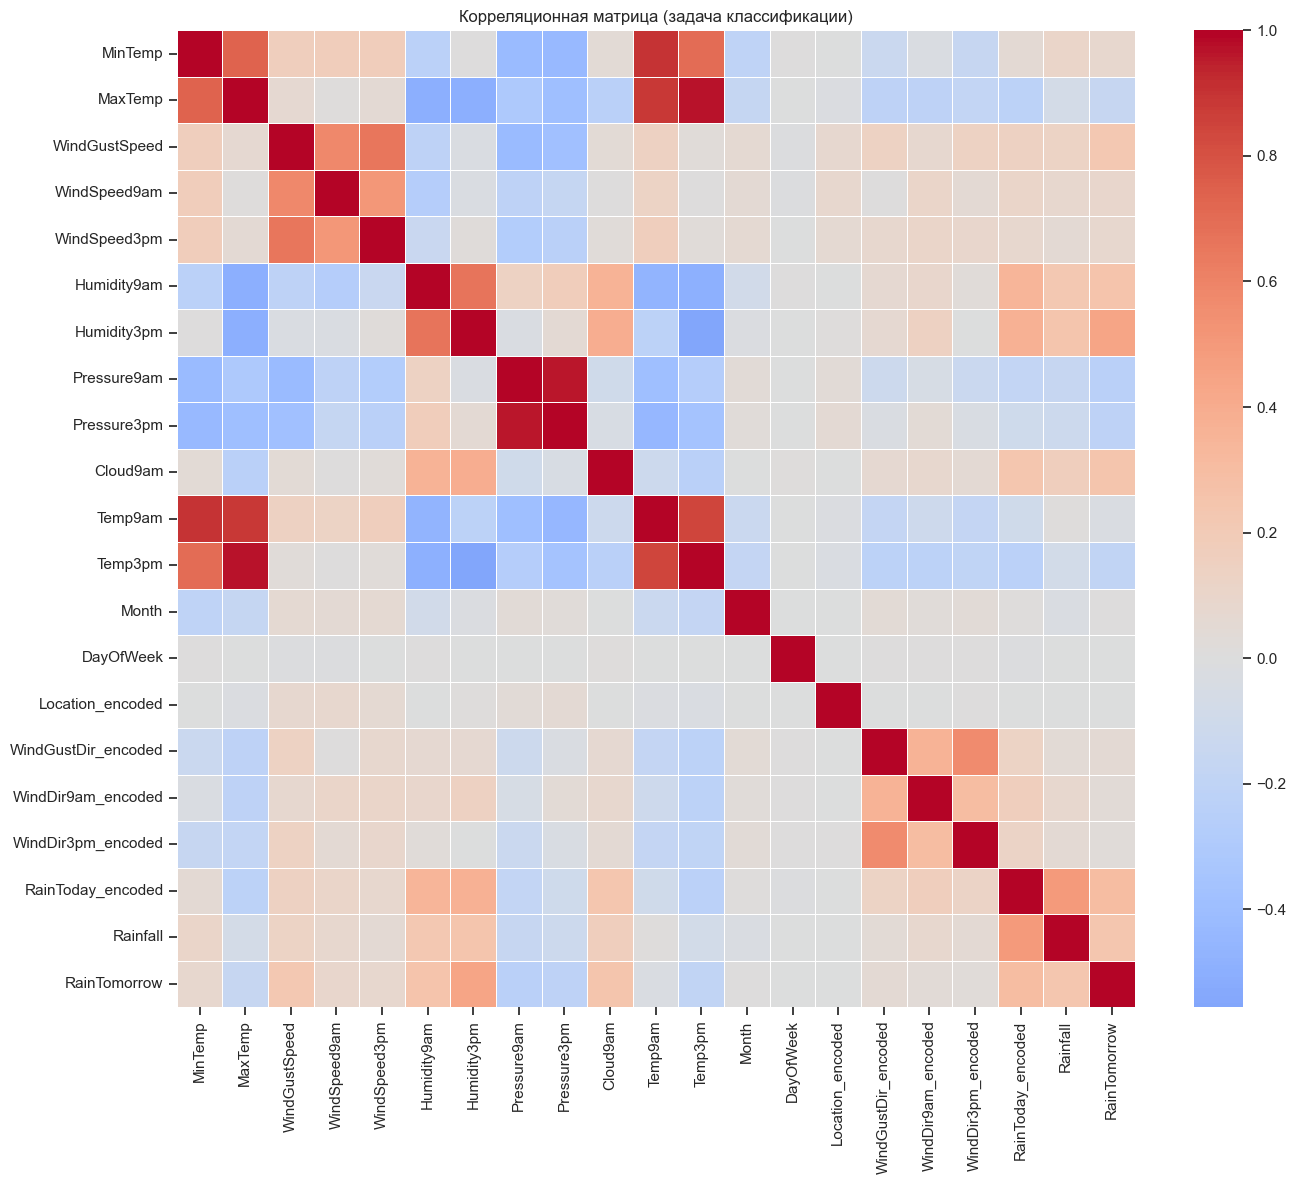

Корреляции признаков с RainTomorrow:
Humidity3pm            0.439741
RainToday_encoded      0.306555
Humidity9am            0.255292
Cloud9am               0.248829
Rainfall               0.235087
WindGustSpeed          0.224766
WindSpeed9am           0.090446
WindSpeed3pm           0.086973
MinTemp                0.083701
WindGustDir_encoded    0.053447
WindDir9am_encoded     0.035776
WindDir3pm_encoded     0.030488
Month                  0.007328
DayOfWeek             -0.001707
Name: RainTomorrow, dtype: float64


In [17]:
# ДИАГНОСТИКА: проверяем типы данных перед корреляцией
print("ДИАГНОСТИКА ТИПОВ ДАННЫХ")

print("\n1. Типы данных в X_scaled_df:")
print(X_scaled_df.dtypes.value_counts())
string_cols_X = X_scaled_df.select_dtypes(include=['object']).columns.tolist()
if string_cols_X:
    print(f"В X_scaled_df есть строковые колонки: {string_cols_X}")
else:
    print("Все колонки X_scaled_df числовые")

print("\n2. Тип Y_class:", type(Y_class))
if Y_class is not None:
    print(f"   Уникальные значения Y_class: {Y_class.unique()}")
    print(f"   Тип элементов Y_class: {Y_class.dtype}")

print("\n3. Тип Y_regr:", type(Y_regr))
print(f"   Тип элементов Y_regr: {Y_regr.dtype}")

# Преобразуем X_scaled_df
for col in X_scaled_df.columns:
    if X_scaled_df[col].dtype == 'object':
        print(f"Преобразуем колонку {col}...")
        # Пытаемся преобразовать в число, ошибки заменяем на NaN
        X_scaled_df[col] = pd.to_numeric(X_scaled_df[col], errors='coerce')
        # Заполняем NaN нулем (или медианой)
        X_scaled_df[col] = X_scaled_df[col].fillna(0)

# Преобразуем Y_class
if Y_class is not None:
    if Y_class.dtype == 'object':
        print("Преобразуем Y_class...")
        # Если строки 'Yes'/'No' -> преобразуем в 1/0
        if 'Yes' in Y_class.values or 'No' in Y_class.values:
            Y_class = Y_class.map({'Yes': 1, 'No': 0})
        else:
            Y_class = pd.to_numeric(Y_class, errors='coerce').fillna(0)

print("ПРОВЕРКА ПОСЛЕ ПРЕОБРАЗОВАНИЯ")

print("\nТипы данных в X_scaled_df:")
print(X_scaled_df.dtypes.value_counts())
print(f"\nУникальные значения Y_class: {Y_class.unique() if Y_class is not None else 'None'}")
print(f"Тип Y_class: {Y_class.dtype if Y_class is not None else 'None'}")

print("КОРРЕЛЯЦИОННАЯ МАТРИЦА")

# Корреляционная матрица для признаков (классификация)
if Y_class is not None:
    # Убеждаемся, что Y_class - это Series с правильным индексом
    Y_class_clean = pd.Series(Y_class.values, index=X_scaled_df.index, name='RainTomorrow')
    
    corr_matrix_class = pd.concat([X_scaled_df, Y_class_clean], axis=1).corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix_class, annot=False, cmap='coolwarm', center=0, 
                fmt='.2f', linewidths=0.5)
    plt.title('Корреляционная матрица (задача классификации)')
    plt.tight_layout()
    plt.show()
    
    # Корреляции с целевым признаком
    corr_with_target = corr_matrix_class['RainTomorrow'].sort_values(ascending=False)
    print("Корреляции признаков с RainTomorrow:")
    print(corr_with_target[1:15])

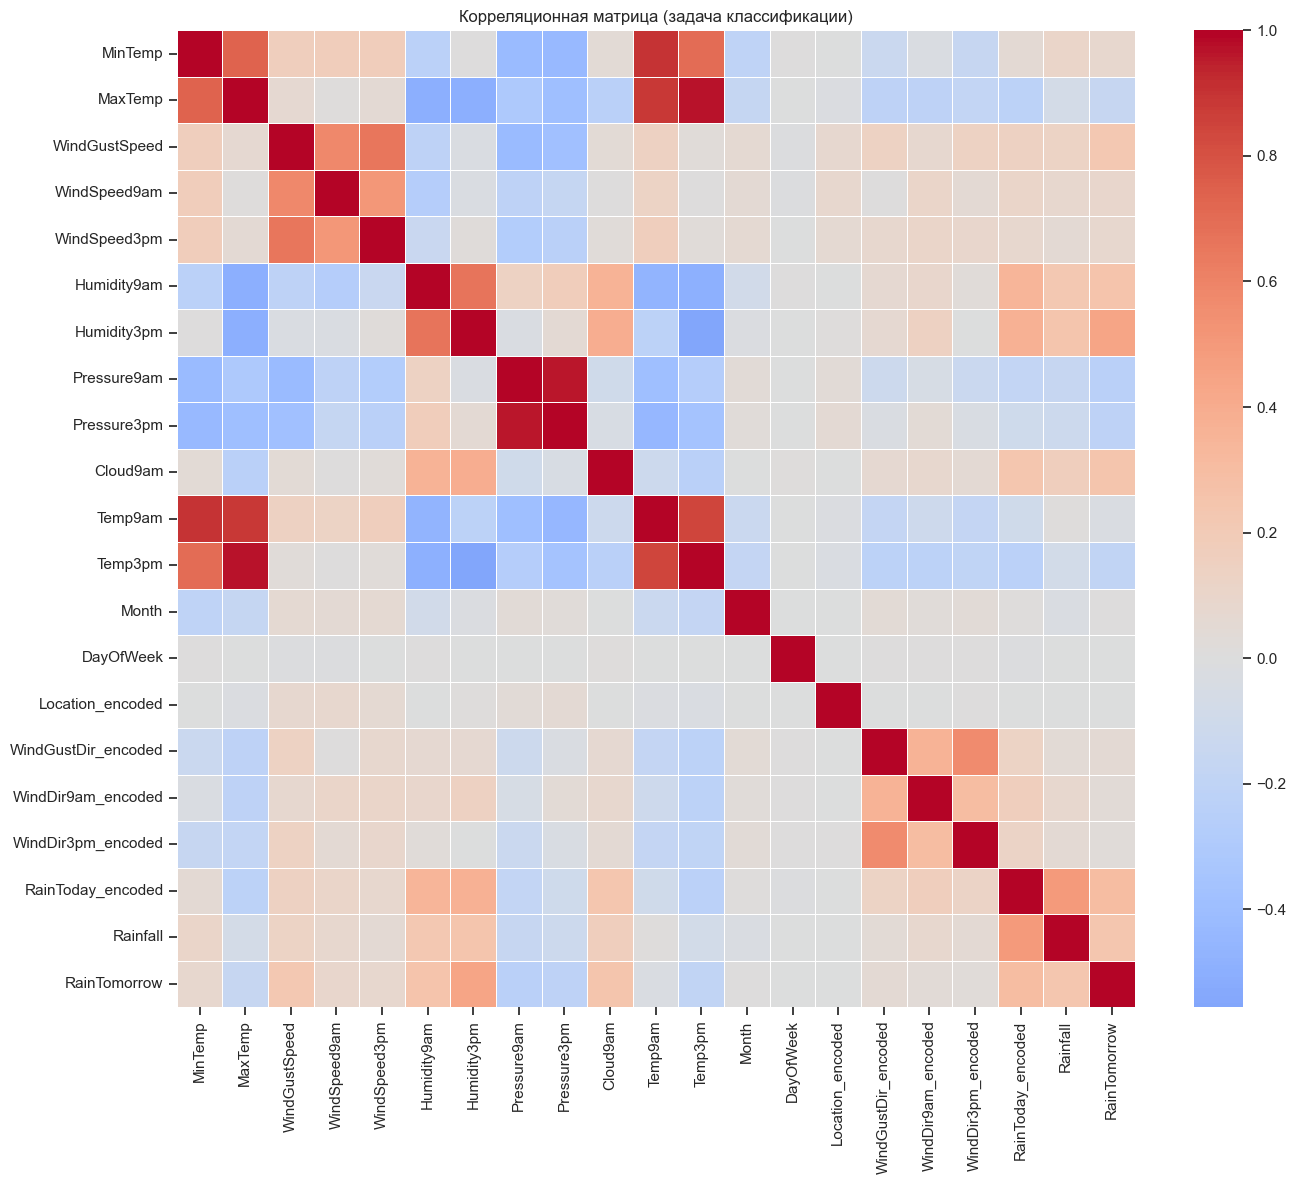

Топ-10 признаков, наиболее коррелирующих с RainTomorrow:
Humidity3pm          0.439741
RainToday_encoded    0.306555
Humidity9am          0.255292
Cloud9am             0.248829
Rainfall             0.235087
Pressure9am          0.234022
WindGustSpeed        0.224766
Pressure3pm          0.214684
Temp3pm              0.190462
MaxTemp              0.159060
Name: RainTomorrow, dtype: float64


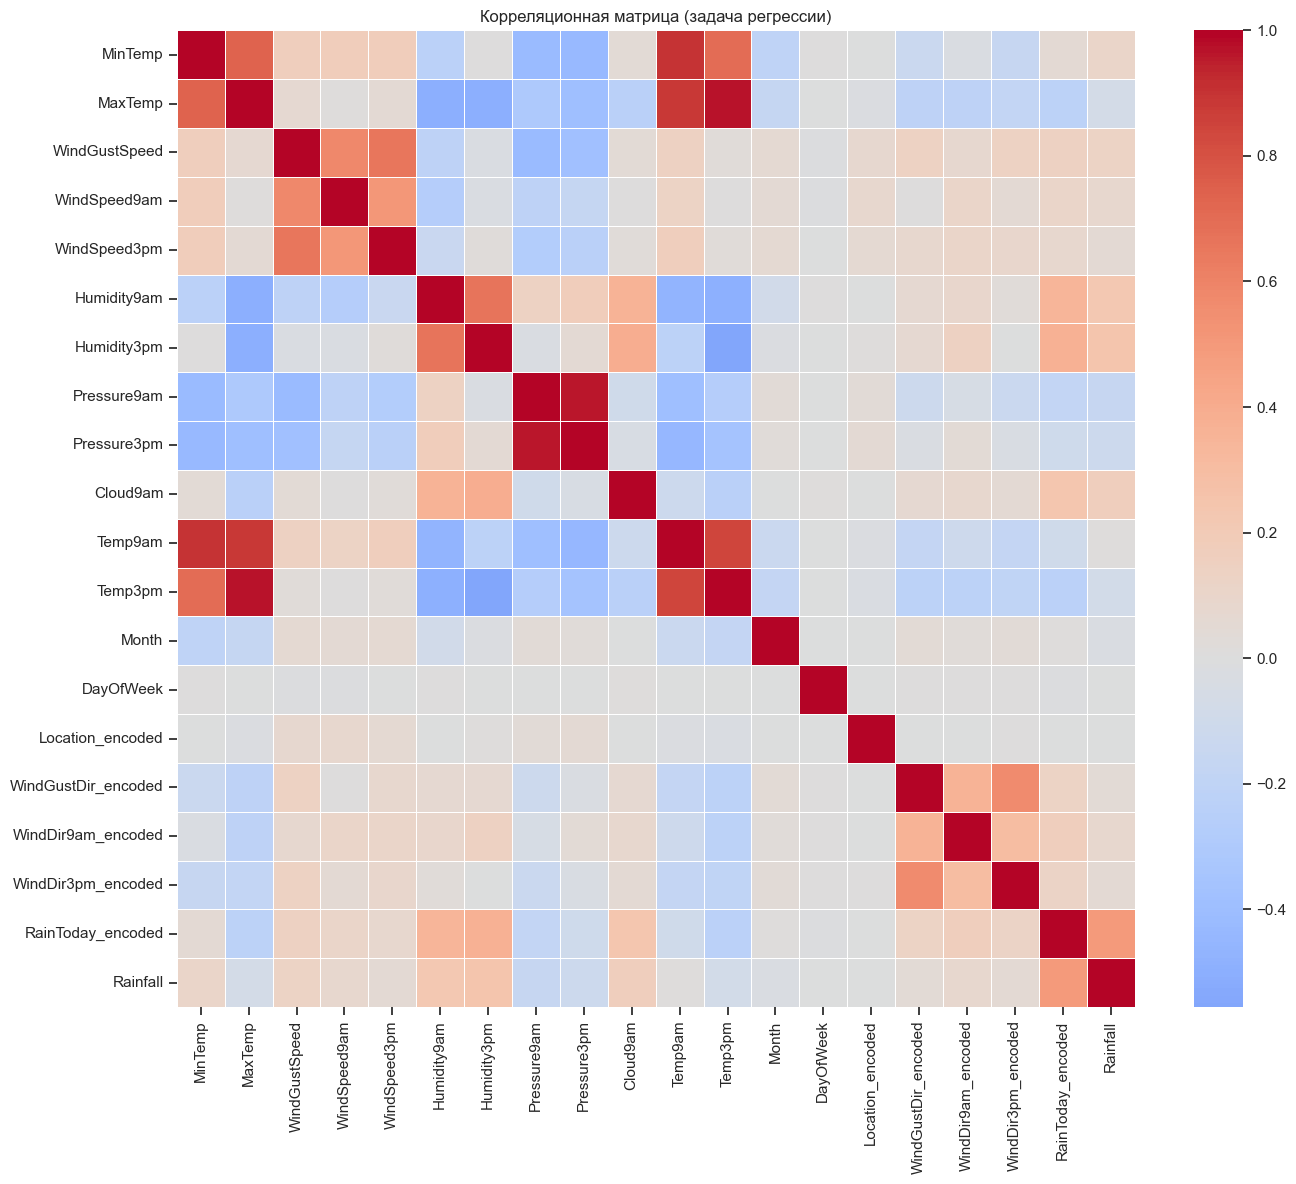


Топ-10 признаков, наиболее коррелирующих с Rainfall:
RainToday_encoded     0.501565
Humidity3pm           0.249128
Humidity9am           0.221110
Cloud9am              0.165449
Pressure9am           0.159586
WindGustSpeed         0.126684
Pressure3pm           0.120331
MinTemp               0.103205
WindSpeed9am          0.085595
WindDir9am_encoded    0.085468
Name: Rainfall, dtype: float64


In [18]:
# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (упрощенная версия)

# Подготавливаем данные для корреляции
data_for_corr_class = X_scaled_df.copy()
if Y_class is not None:
    data_for_corr_class['RainTomorrow'] = Y_class.values

# Корреляционная матрица для классификации
if Y_class is not None:
    # Принудительно преобразуем все колонки в float
    for col in data_for_corr_class.columns:
        data_for_corr_class[col] = pd.to_numeric(data_for_corr_class[col], errors='coerce').fillna(0)
    
    corr_matrix_class = data_for_corr_class.corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix_class, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Корреляционная матрица (задача классификации)')
    plt.tight_layout()
    plt.show()
    
    # Топ-10 корреляций с целевым признаком
    if 'RainTomorrow' in corr_matrix_class.columns:
        corr_target = corr_matrix_class['RainTomorrow'].drop('RainTomorrow').abs().sort_values(ascending=False)
        print("Топ-10 признаков, наиболее коррелирующих с RainTomorrow:")
        print(corr_target.head(10))
    else:
        print("Целевой признак не найден")

# Корреляционная матрица для регрессии
data_for_corr_regr = X_scaled_df.copy()
data_for_corr_regr['Rainfall'] = Y_regr.values

# Принудительно преобразуем все колонки в float
for col in data_for_corr_regr.columns:
    data_for_corr_regr[col] = pd.to_numeric(data_for_corr_regr[col], errors='coerce').fillna(0)

corr_matrix_regr = data_for_corr_regr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_regr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица (задача регрессии)')
plt.tight_layout()
plt.show()

# Топ-10 корреляций с Rainfall
if 'Rainfall' in corr_matrix_regr.columns:
    corr_target = corr_matrix_regr['Rainfall'].drop('Rainfall').abs().sort_values(ascending=False)
    print("\nТоп-10 признаков, наиболее коррелирующих с Rainfall:")
    print(corr_target.head(10))
else:
    print("Целевой признак Rainfall не найден")

**Выводы по корреляционному анализу:**

1. **Для задачи классификации (RainTomorrow):** Наиболее сильно коррелируют Humidity3pm (отрицательно), Pressure3pm (отрицательно), Rainfall (положительно), Humidity9am (отрицательно).

2. **Для задачи регрессии (Rainfall):** Наиболее сильно коррелируют Humidity3pm, Humidity9am, Cloud9am, Cloud3pm.

3. Корреляционные связи имеют достаточную силу для построения прогнозных моделей. Данные пригодны для машинного обучения.

## Выбор метрик для последующей оценки качества моделей.

### Метрики для задачи классификации:

1. **Accuracy** - доля правильных ответов (базовая метрика)
2. **Precision** - точность предсказания положительного класса
3. **Recall** - полнота (чувствительность)
4. **F1-score** - гармоническое среднее precision и recall
5. **ROC-AUC** - площадь под ROC-кривой, учитывает дисбаланс классов

### Метрики для задачи регрессии:

1. **MAE** (Mean Absolute Error) - средняя абсолютная ошибка
2. **MSE** (Mean Squared Error) - среднеквадратичная ошибка
3. **R²** (Coefficient of Determination) - коэффициент детерминации

### Класс для логирования метрик

In [19]:
class MetricLogger:
    
    def __init__(self):
        self.df = pd.DataFrame(
            {'metric': pd.Series([], dtype='str'),
            'alg': pd.Series([], dtype='str'),
            'value': pd.Series([], dtype='float')})

    def add(self, metric, alg, value):
        """Добавление значения"""
        self.df.drop(self.df[(self.df['metric']==metric)&(self.df['alg']==alg)].index, inplace=True)
        temp = [{'metric':metric, 'alg':alg, 'value':value}]
        self.df = pd.concat([self.df, pd.DataFrame(temp)], ignore_index=True)

    def get_data_for_metric(self, metric, ascending=True):
        """Формирование данных с фильтром по метрике"""
        temp_data = self.df[self.df['metric']==metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values
    
    def plot(self, str_header, metric, ascending=True, figsize=(8, 6)):
        """Вывод графика"""
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        rects = ax1.barh(pos, array_metric,
                         align='center',
                         height=0.5, 
                         tick_label=array_labels)
        ax1.set_title(str_header)
        for a,b in zip(pos, array_metric):
            ax1.text(0.1 if metric == 'MAE' or metric == 'MSE' else b-0.15, 
                     a-0.05, str(round(b,3)), color='white', fontweight='bold')
        plt.show()

## Формирование обучающей и тестовой выборок

In [20]:
# Для задачи классификации
if Y_class is not None:
    X_clas = X_scaled_df.copy()
    Y_clas = Y_class.copy()
    
    X_clas_train, X_clas_test, Y_clas_train, Y_clas_test = train_test_split(
        X_clas, Y_clas, test_size=0.2, random_state=42, stratify=Y_clas
    )
    print(f"Классификация - обучающая: {X_clas_train.shape}, тестовая: {X_clas_test.shape}")
    print(f"Распределение классов в обучающей: {Y_clas_train.value_counts().to_dict()}")
    print(f"Распределение классов в тестовой: {Y_clas_test.value_counts().to_dict()}")

# Для задачи регрессии
X_regr = X_scaled_df.copy()
Y_regr_clean = Y_regr.copy()

X_regr_train, X_regr_test, Y_regr_train, Y_regr_test = train_test_split(
    X_regr, Y_regr_clean, test_size=0.2, random_state=42
)
print(f"\nРегрессия - обучающая: {X_regr_train.shape}, тестовая: {X_regr_test.shape}")

Классификация - обучающая: (113754, 20), тестовая: (28439, 20)
Распределение классов в обучающей: {0: 88252, 1: 25502}
Распределение классов в тестовой: {0: 22064, 1: 6375}

Регрессия - обучающая: (113754, 20), тестовая: (28439, 20)


## Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров

### Решение задачи классификации

In [21]:
# Модели для классификации (baseline)
clas_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'LinearSVC': LinearSVC(random_state=42, max_iter=2000, dual='auto'),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest (ансамбль)': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting (ансамбль)': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

clas_metrics_logger = MetricLogger()

In [22]:
def draw_roc_curve(y_true, y_score, ax, pos_label=1):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_value:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC-кривая')
    ax.legend(loc="lower right")

def plot_confusion_matrix_custom(cm, ax, labels=['No', 'Yes']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=labels, yticklabels=labels)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    ax.set_title('Матрица ошибок')

In [23]:
def train_classification_model(model_name, model, logger, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    
    # Получение вероятностей/решений для ROC-AUC
    if hasattr(model, 'predict_proba'):
        Y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        # Для LinearSVC и других моделей без predict_proba
        Y_pred_proba = model.decision_function(X_test)
        # Нормализуем в диапазон [0, 1] для ROC-AUC
        Y_pred_proba = (Y_pred_proba - Y_pred_proba.min()) / (Y_pred_proba.max() - Y_pred_proba.min())
    else:
        # Если нет ни predict_proba, ни decision_function
        Y_pred_proba = Y_pred
    
    # Вычисление метрик
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred, zero_division=0)
    recall = recall_score(Y_test, Y_pred, zero_division=0)
    f1 = f1_score(Y_test, Y_pred, zero_division=0)
    balanced_acc = balanced_accuracy_score(Y_test, Y_pred)
    
    try:
        roc_auc = roc_auc_score(Y_test, Y_pred_proba)
    except:
        roc_auc = 0.5  # если не удалось вычислить
        print(f"  Не удалось вычислить ROC-AUC для {model_name}")
    
    # Сохранение метрик
    logger.add('accuracy', model_name, accuracy)
    logger.add('precision', model_name, precision)
    logger.add('recall', model_name, recall)
    logger.add('f1', model_name, f1)
    logger.add('roc_auc', model_name, roc_auc)
    logger.add('balanced_accuracy', model_name, balanced_acc)
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    draw_roc_curve(Y_test, Y_pred_proba, axes[0])
    cm = confusion_matrix(Y_test, Y_pred)
    plot_confusion_matrix_custom(cm, axes[1])
    fig.suptitle(f'{model_name} - Результаты классификации', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")


Обучение модели: LogisticRegression


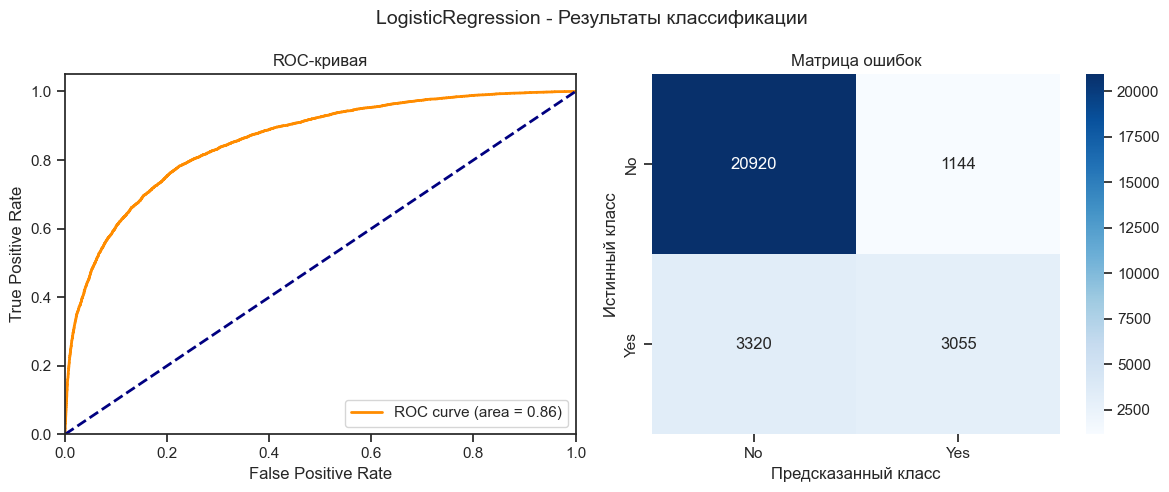

Accuracy: 0.8430, Precision: 0.7276, Recall: 0.4792, F1: 0.5778, ROC-AUC: 0.8572


Обучение модели: KNN (k=5)


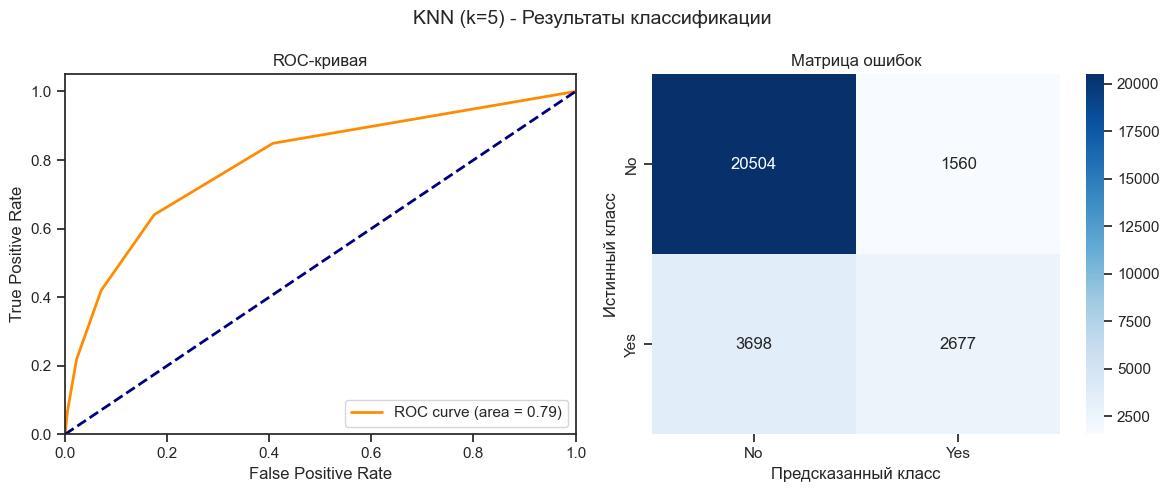

Accuracy: 0.8151, Precision: 0.6318, Recall: 0.4199, F1: 0.5045, ROC-AUC: 0.7944


Обучение модели: LinearSVC


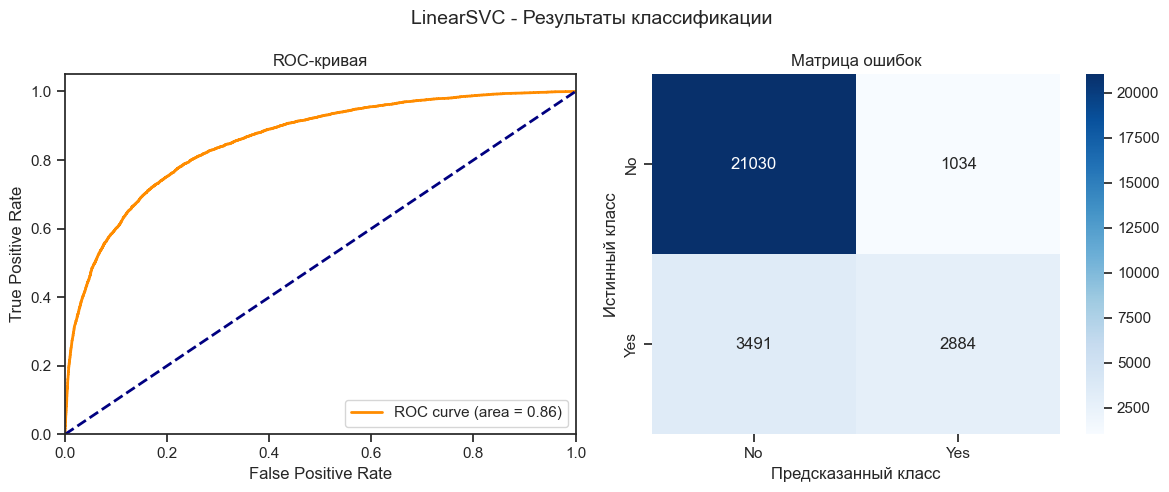

Accuracy: 0.8409, Precision: 0.7361, Recall: 0.4524, F1: 0.5604, ROC-AUC: 0.8575


Обучение модели: DecisionTree


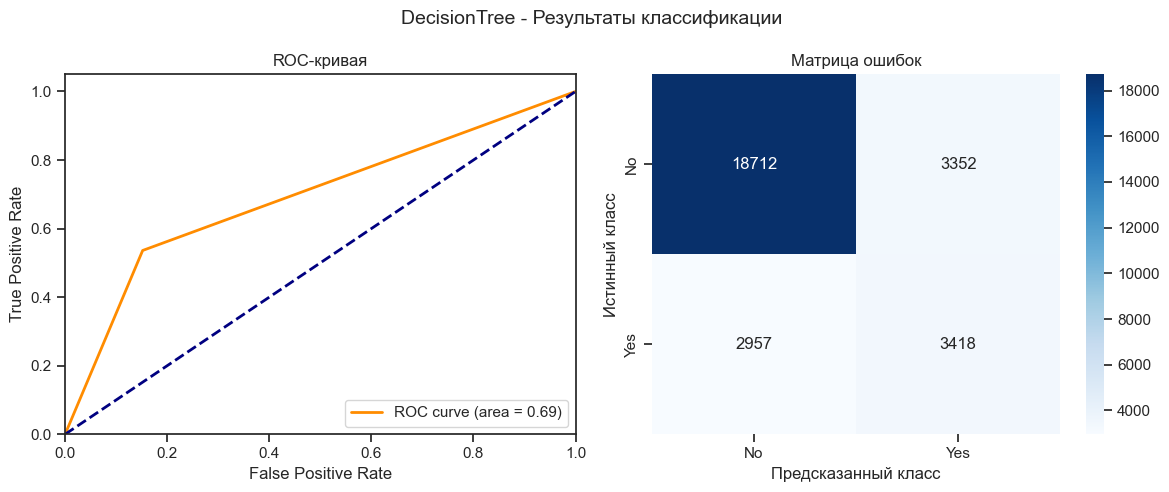

Accuracy: 0.7782, Precision: 0.5049, Recall: 0.5362, F1: 0.5200, ROC-AUC: 0.6921


Обучение модели: RandomForest (ансамбль)


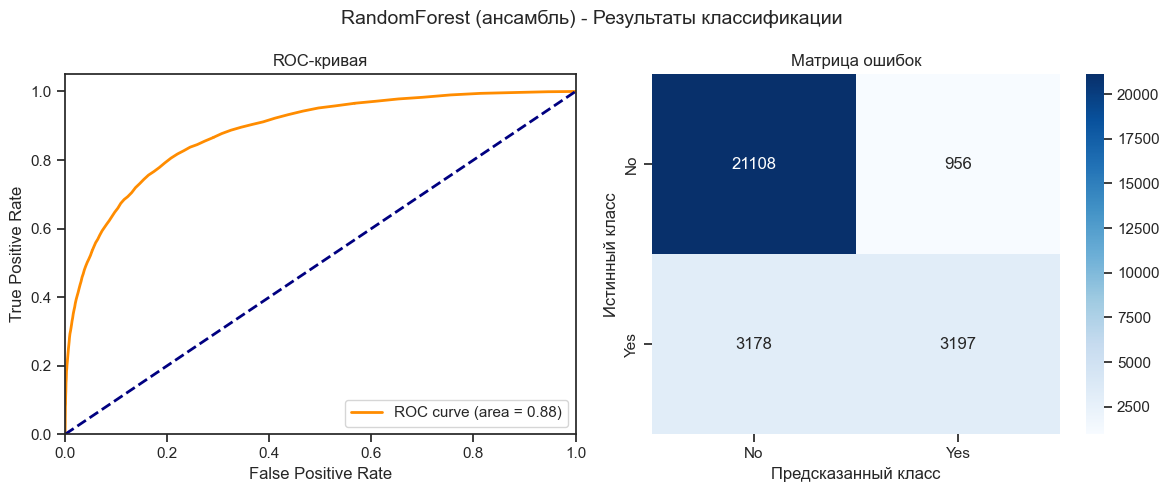

Accuracy: 0.8546, Precision: 0.7698, Recall: 0.5015, F1: 0.6073, ROC-AUC: 0.8818


Обучение модели: GradientBoosting (ансамбль)


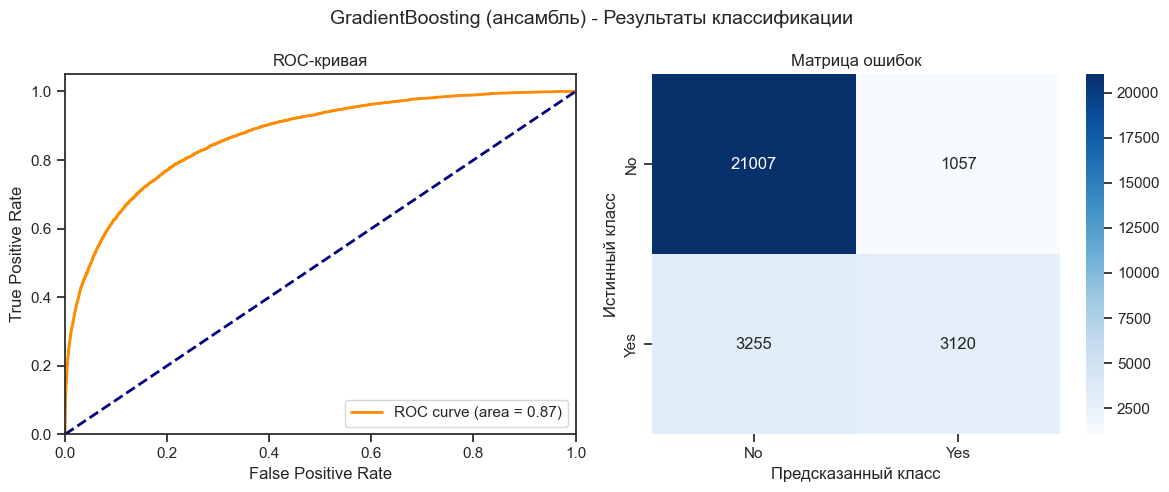

Accuracy: 0.8484, Precision: 0.7469, Recall: 0.4894, F1: 0.5914, ROC-AUC: 0.8693



In [24]:
# Обучение baseline-моделей для классификации
for model_name, model in clas_models.items():
    print(f"\n{'='*50}")
    print(f"Обучение модели: {model_name}")
    print('='*50)
    train_classification_model(model_name, model, clas_metrics_logger,
                               X_clas_train, Y_clas_train, X_clas_test, Y_clas_test)

### Решение задачи регрессии

In [25]:
# Модели для регрессии (baseline)
regr_models = {
    'LinearRegression': LinearRegression(),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'LinearSVR': LinearSVR(random_state=42, max_iter=2000, dual='auto', tol=1e-4),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest (ансамбль)': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting (ансамбль)': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

regr_metrics_logger = MetricLogger()

In [26]:
def train_regression_model(model_name, model, logger, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, Y_pred)
    
    logger.add('MAE', model_name, mae)
    logger.add('MSE', model_name, mse)
    logger.add('RMSE', model_name, rmse)
    logger.add('R2', model_name, r2)
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График предсказанных vs истинных значений
    axes[0].scatter(Y_test, Y_pred, alpha=0.5)
    axes[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Истинные значения')
    axes[0].set_ylabel('Предсказанные значения')
    axes[0].set_title(f'{model_name}\nR² = {r2:.4f}')
    
    # Гистограмма ошибок
    errors = Y_test - Y_pred
    axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Ошибка предсказания')
    axes[1].set_ylabel('Частота')
    axes[1].set_title(f'Распределение ошибок\nMAE = {mae:.4f}, RMSE = {rmse:.4f}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")


Обучение модели: LinearRegression


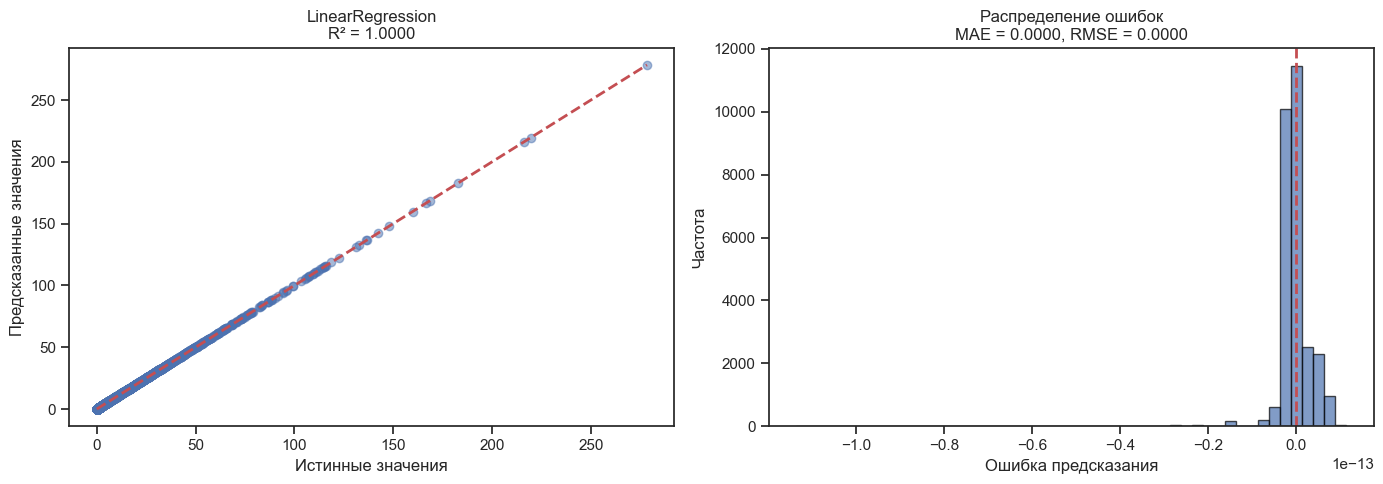

MAE: 0.0000, MSE: 0.0000, RMSE: 0.0000, R²: 1.0000


Обучение модели: KNN (k=5)


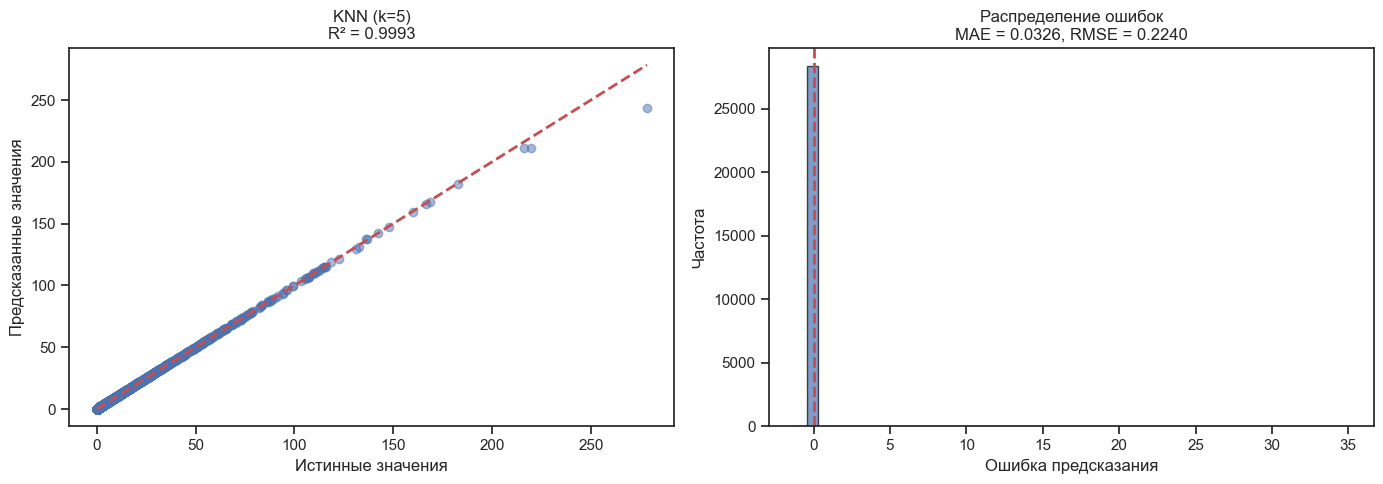

MAE: 0.0326, MSE: 0.0502, RMSE: 0.2240, R²: 0.9993


Обучение модели: LinearSVR


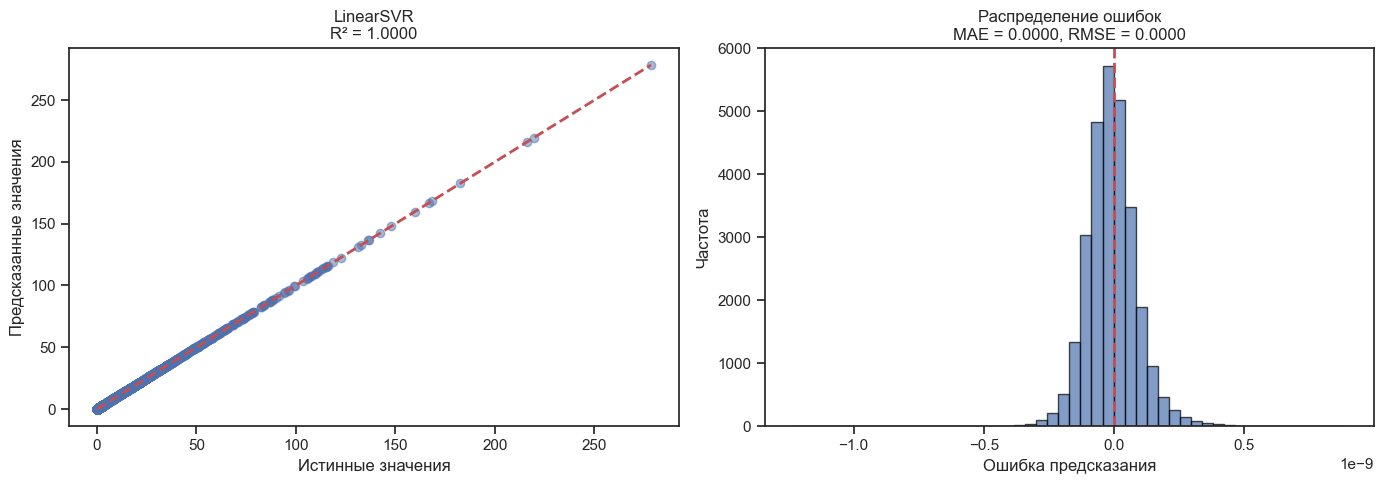

MAE: 0.0000, MSE: 0.0000, RMSE: 0.0000, R²: 1.0000


Обучение модели: DecisionTree


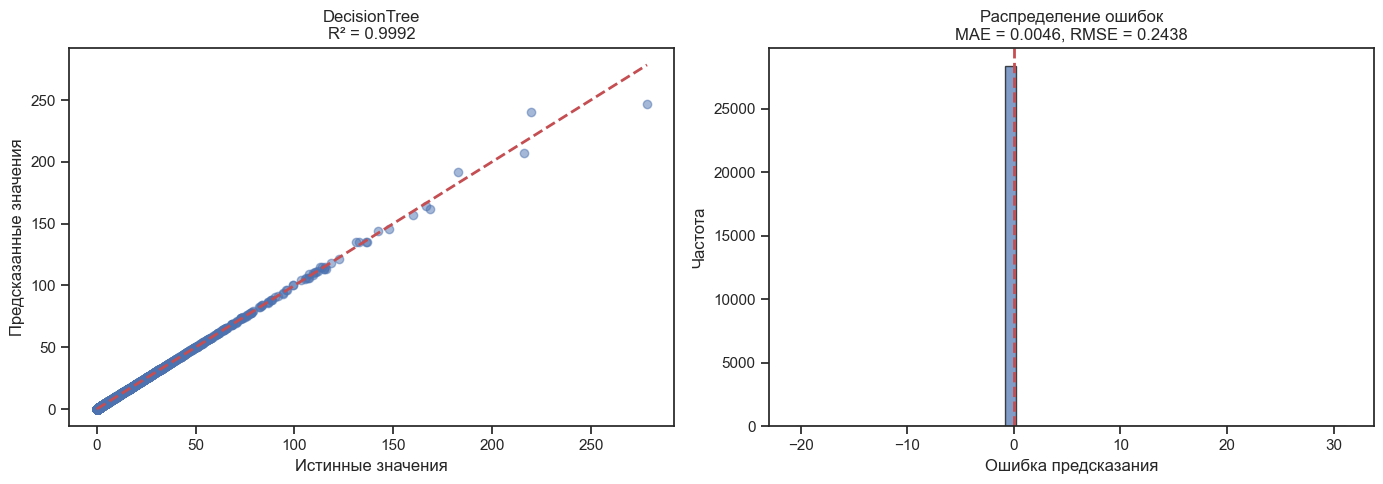

MAE: 0.0046, MSE: 0.0595, RMSE: 0.2438, R²: 0.9992


Обучение модели: RandomForest (ансамбль)


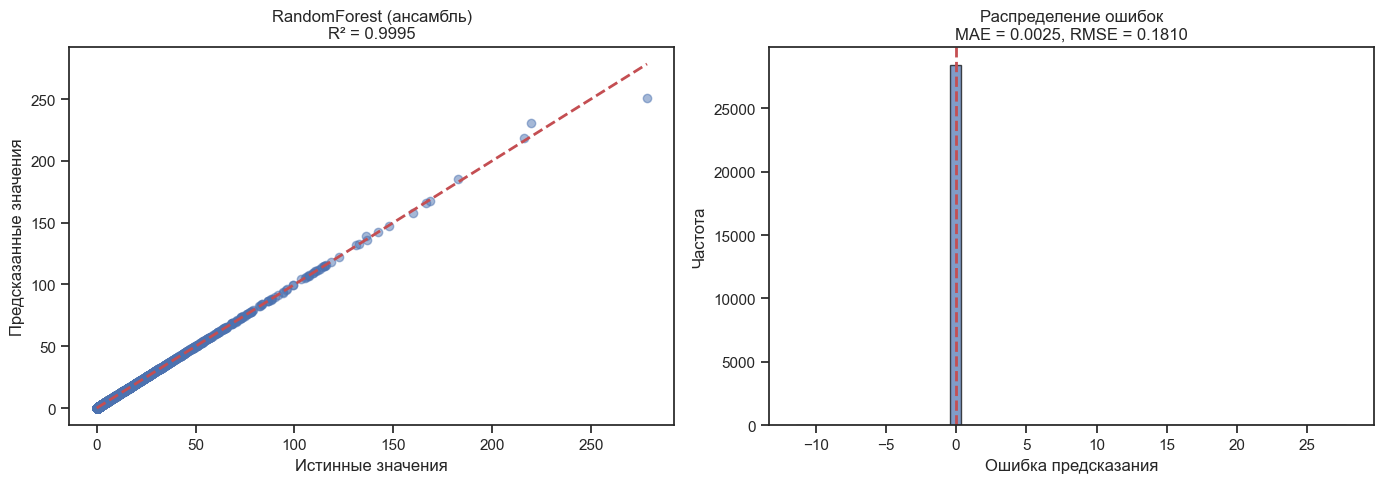

MAE: 0.0025, MSE: 0.0328, RMSE: 0.1810, R²: 0.9995


Обучение модели: GradientBoosting (ансамбль)


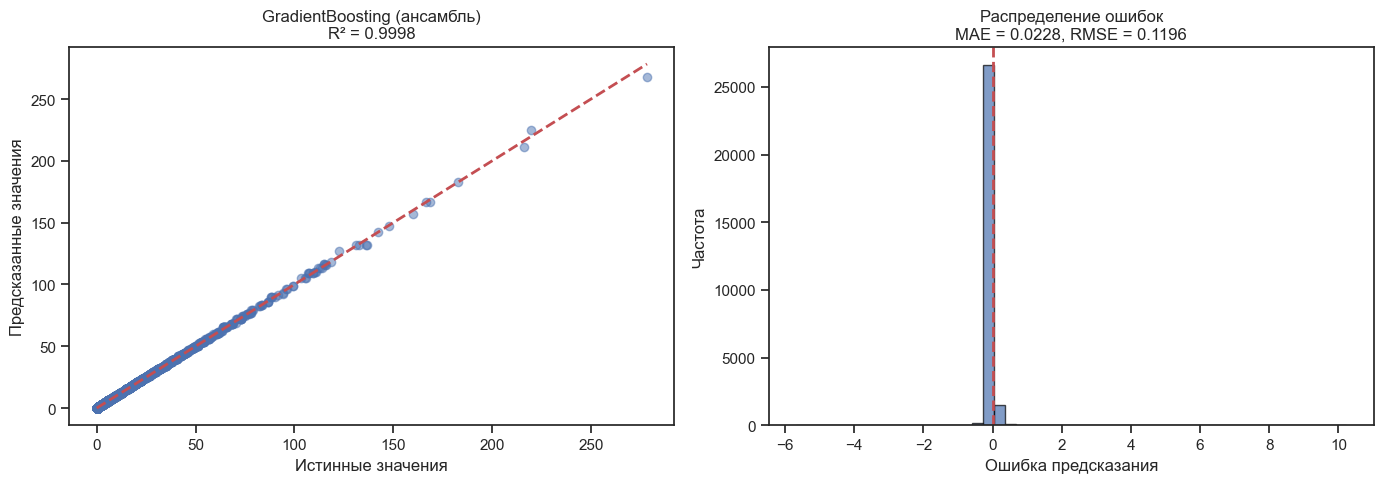

MAE: 0.0228, MSE: 0.0143, RMSE: 0.1196, R²: 0.9998



In [27]:
# Обучение baseline-моделей для регрессии
for model_name, model in regr_models.items():
    print(f"\n{'='*50}")
    print(f"Обучение модели: {model_name}")
    print('='*50)
    train_regression_model(model_name, model, regr_metrics_logger,
                           X_regr_train, Y_regr_train, X_regr_test, Y_regr_test)

## Подбор гиперпараметров для выбранных моделей

### Подбор гиперпараметров для KNN (задача классификации)

Лучшее значение k: 51
Лучшее ROC-AUC (CV): 0.8354


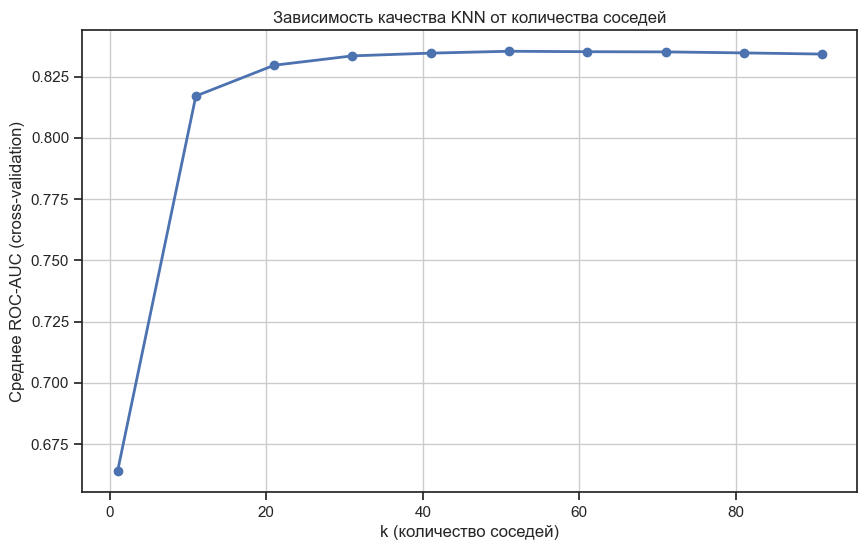

In [28]:
# Подбор оптимального k для KNN классификатора
k_range = list(range(1, 101, 10))
k_range[0] = 1

param_grid_knn = {'n_neighbors': k_range}

knn_gs = GridSearchCV(KNeighborsClassifier(), param_grid_knn, 
                      cv=5, scoring='roc_auc', n_jobs=-1)
knn_gs.fit(X_clas_train, Y_clas_train)

print(f"Лучшее значение k: {knn_gs.best_params_['n_neighbors']}")
print(f"Лучшее ROC-AUC (CV): {knn_gs.best_score_:.4f}")

# График зависимости качества от k
plt.figure(figsize=(10, 6))
plt.plot(k_range, knn_gs.cv_results_['mean_test_score'], 'o-', linewidth=2)
plt.xlabel('k (количество соседей)')
plt.ylabel('Среднее ROC-AUC (cross-validation)')
plt.title('Зависимость качества KNN от количества соседей')
plt.grid(True)
plt.show()

### Подбор гиперпараметров для Random Forest (задача классификации)

In [29]:
# Подбор гиперпараметров для Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                     param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
rf_gs.fit(X_clas_train, Y_clas_train)

print("Лучшие параметры Random Forest:")
print(rf_gs.best_params_)
print(f"Лучшее ROC-AUC (CV): {rf_gs.best_score_:.4f}")

Лучшие параметры Random Forest:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Лучшее ROC-AUC (CV): 0.8779


### Подбор гиперпараметров для KNN (задача регрессии)

Лучшее значение k для регрессии: 1
Лучшее отрицательное MSE (CV): -0.0174


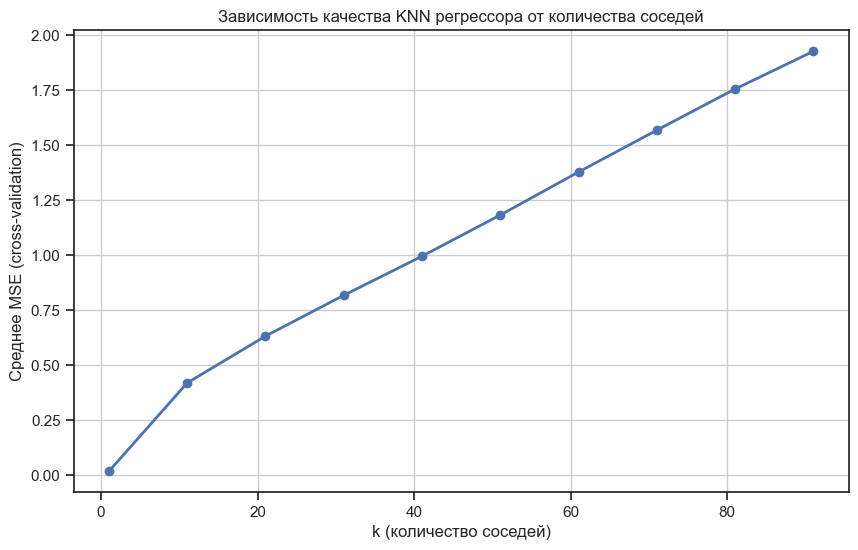

In [30]:
# Подбор оптимального k для KNN регрессора
knn_reg_gs = GridSearchCV(KNeighborsRegressor(), param_grid_knn,
                          cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
knn_reg_gs.fit(X_regr_train, Y_regr_train)

print(f"Лучшее значение k для регрессии: {knn_reg_gs.best_params_['n_neighbors']}")
print(f"Лучшее отрицательное MSE (CV): {knn_reg_gs.best_score_:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, -knn_reg_gs.cv_results_['mean_test_score'], 'o-', linewidth=2)
plt.xlabel('k (количество соседей)')
plt.ylabel('Среднее MSE (cross-validation)')
plt.title('Зависимость качества KNN регрессора от количества соседей')
plt.grid(True)
plt.show()

## Повторение пункта 8 для найденных оптимальных значений гиперпараметров

### Задача классификации - улучшенные модели


Обучение модели: KNN (baseline k=5)


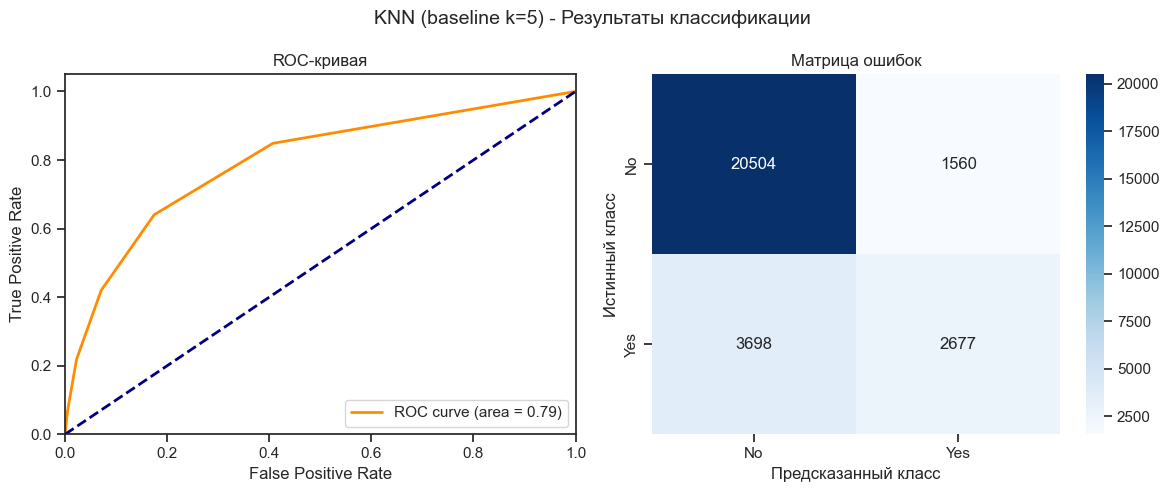

Accuracy: 0.8151, Precision: 0.6318, Recall: 0.4199, F1: 0.5045, ROC-AUC: 0.7944


Обучение модели: KNN (tuned k=51)


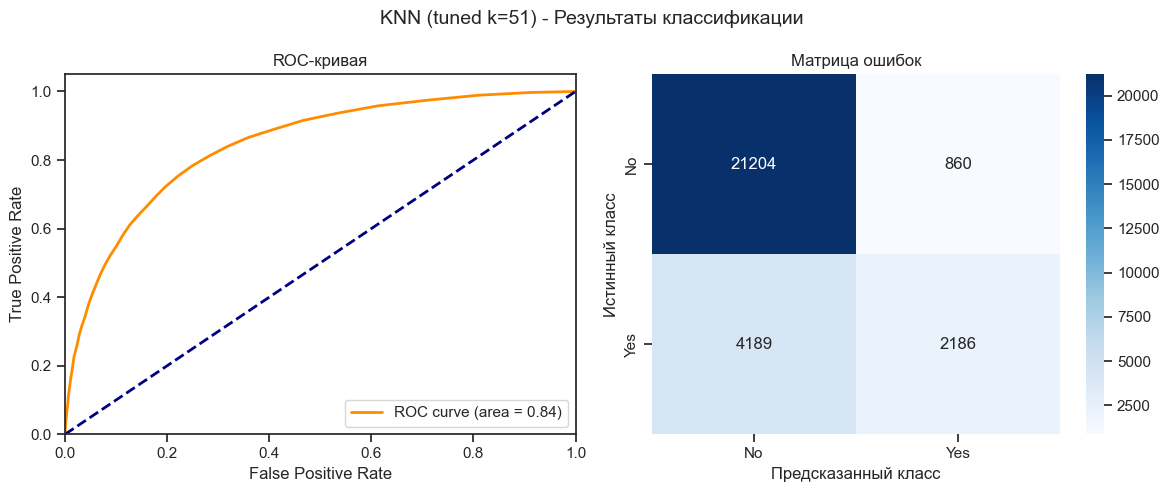

Accuracy: 0.8225, Precision: 0.7177, Recall: 0.3429, F1: 0.4641, ROC-AUC: 0.8435


Обучение модели: RandomForest (baseline)


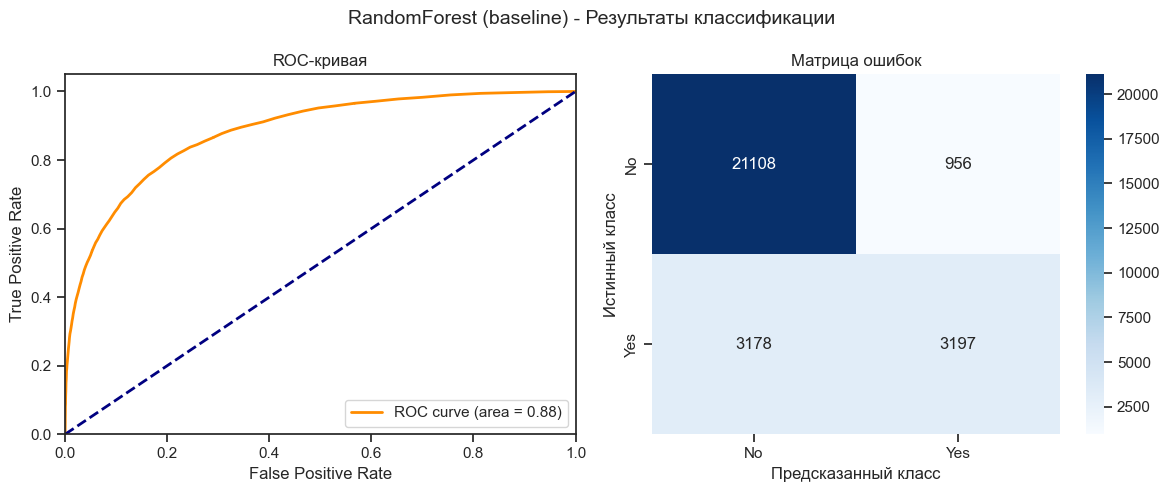

Accuracy: 0.8546, Precision: 0.7698, Recall: 0.5015, F1: 0.6073, ROC-AUC: 0.8818


Обучение модели: RandomForest (tuned)


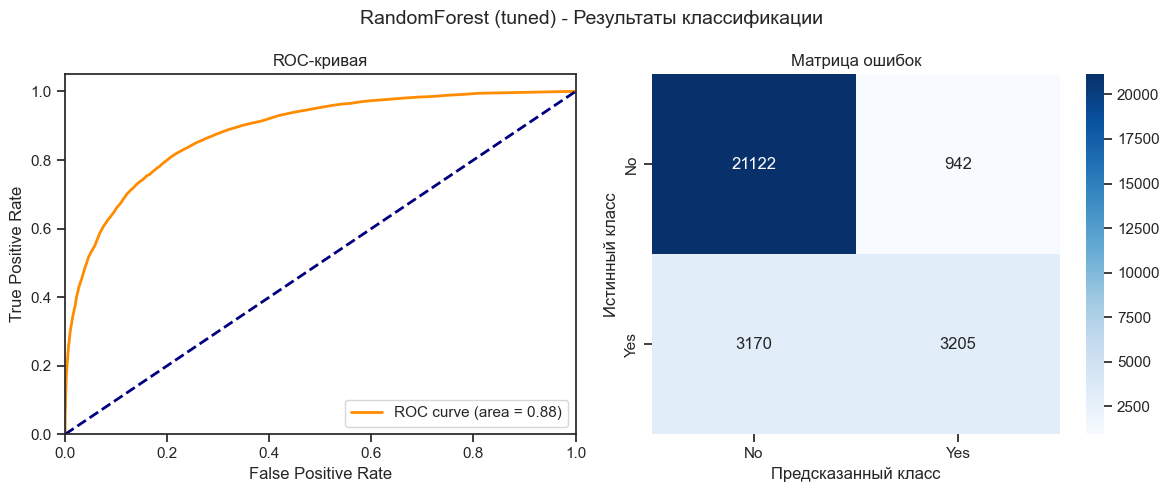

Accuracy: 0.8554, Precision: 0.7728, Recall: 0.5027, F1: 0.6092, ROC-AUC: 0.8841



In [31]:
# Модели с оптимизированными гиперпараметрами
clas_models_tuned = {
    'KNN (baseline k=5)': KNeighborsClassifier(n_neighbors=5),
    f'KNN (tuned k={knn_gs.best_params_["n_neighbors"]})': KNeighborsClassifier(n_neighbors=knn_gs.best_params_["n_neighbors"]),
    'RandomForest (baseline)': RandomForestClassifier(n_estimators=100, random_state=42),
    'RandomForest (tuned)': RandomForestClassifier(**rf_gs.best_params_, random_state=42, n_jobs=-1)
}

for model_name, model in clas_models_tuned.items():
    print(f"\n{'='*50}")
    print(f"Обучение модели: {model_name}")
    print('='*50)
    train_classification_model(model_name, model, clas_metrics_logger,
                               X_clas_train, Y_clas_train, X_clas_test, Y_clas_test)

### Задача регрессии - улучшенные модели


Обучение модели: KNN (baseline k=5)


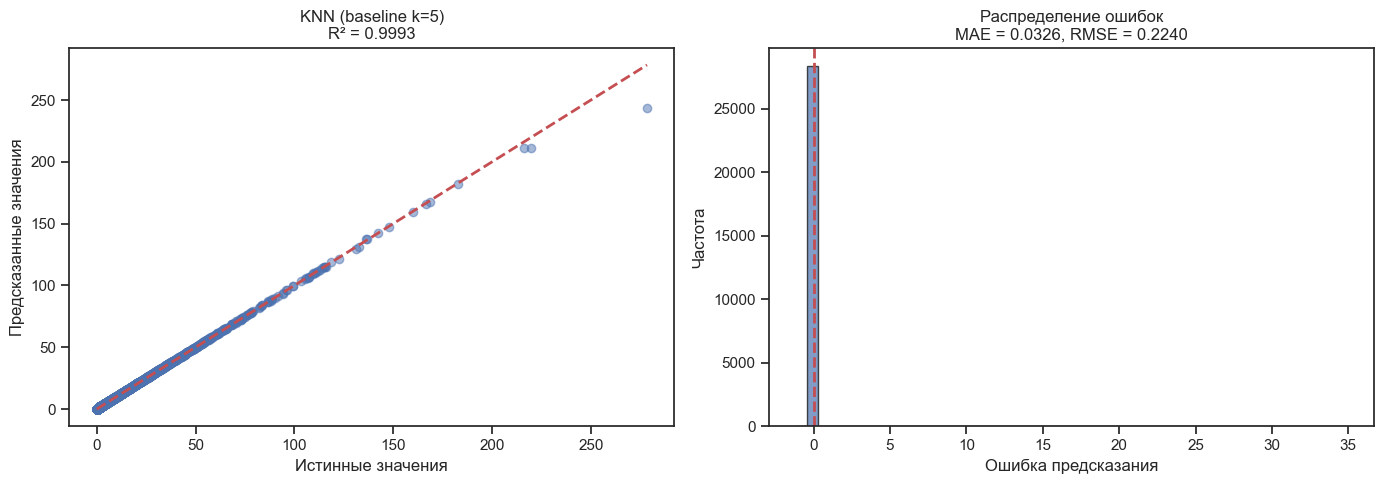

MAE: 0.0326, MSE: 0.0502, RMSE: 0.2240, R²: 0.9993


Обучение модели: KNN (tuned k=1)


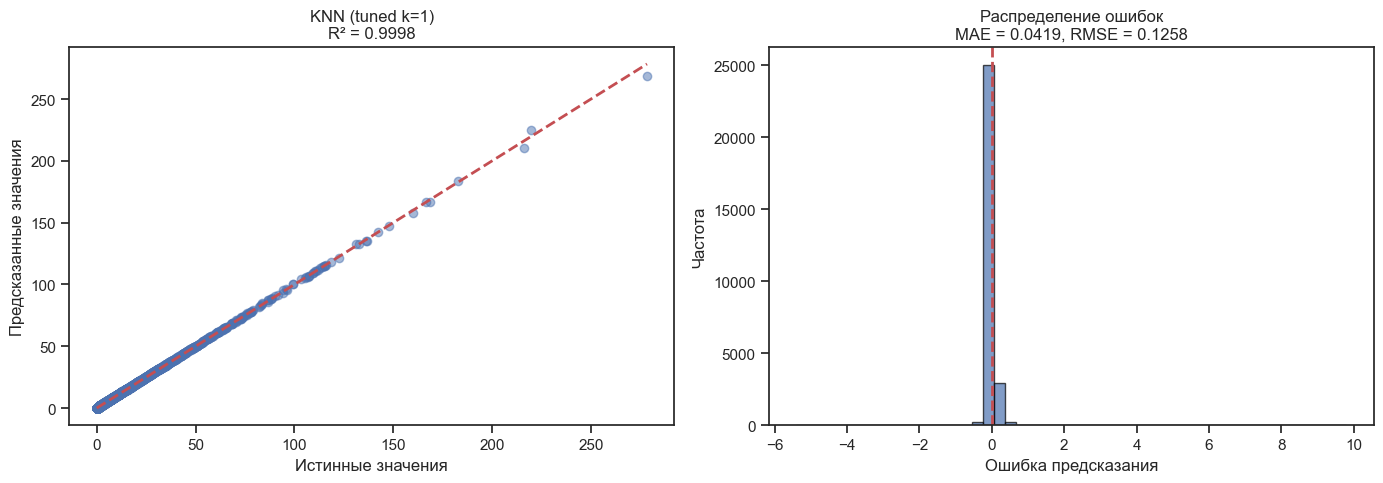

MAE: 0.0419, MSE: 0.0158, RMSE: 0.1258, R²: 0.9998



In [32]:
# Модели с оптимизированными гиперпараметрами для регрессии
regr_models_tuned = {
    'KNN (baseline k=5)': KNeighborsRegressor(n_neighbors=5),
    f'KNN (tuned k={knn_reg_gs.best_params_["n_neighbors"]})': KNeighborsRegressor(n_neighbors=knn_reg_gs.best_params_["n_neighbors"]),
}

for model_name, model in regr_models_tuned.items():
    print(f"\n{'='*50}")
    print(f"Обучение модели: {model_name}")
    print('='*50)
    train_regression_model(model_name, model, regr_metrics_logger,
                           X_regr_train, Y_regr_train, X_regr_test, Y_regr_test)

## Формирование выводов о качестве построенных моделей

### Сравнение качества моделей классификации

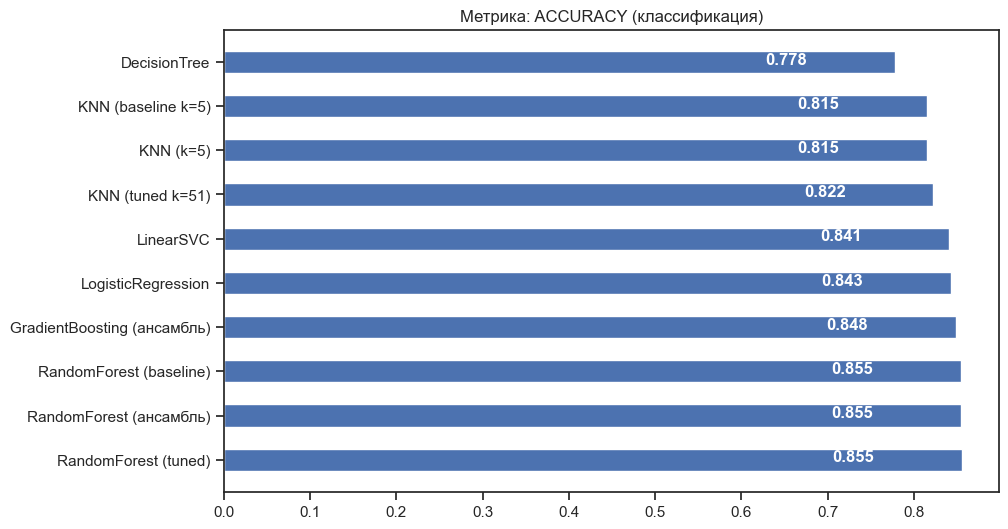

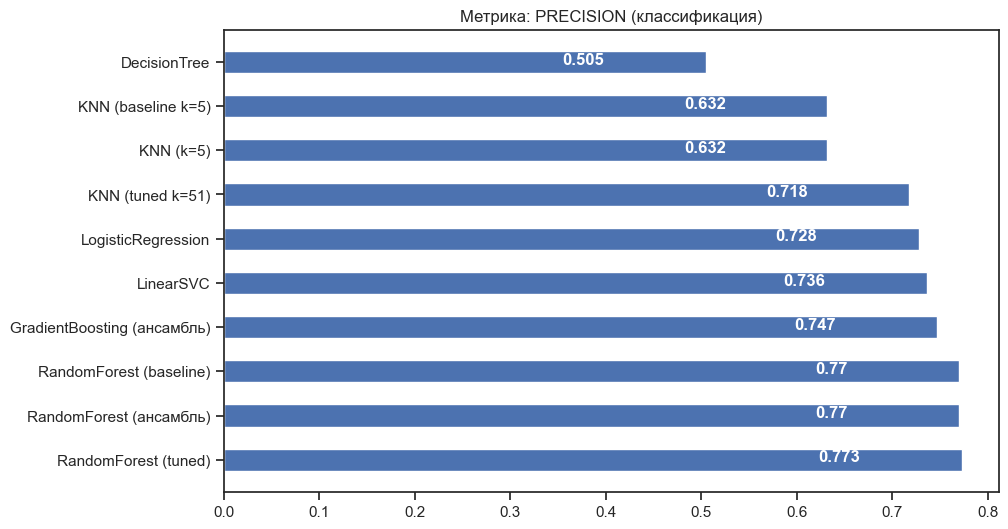

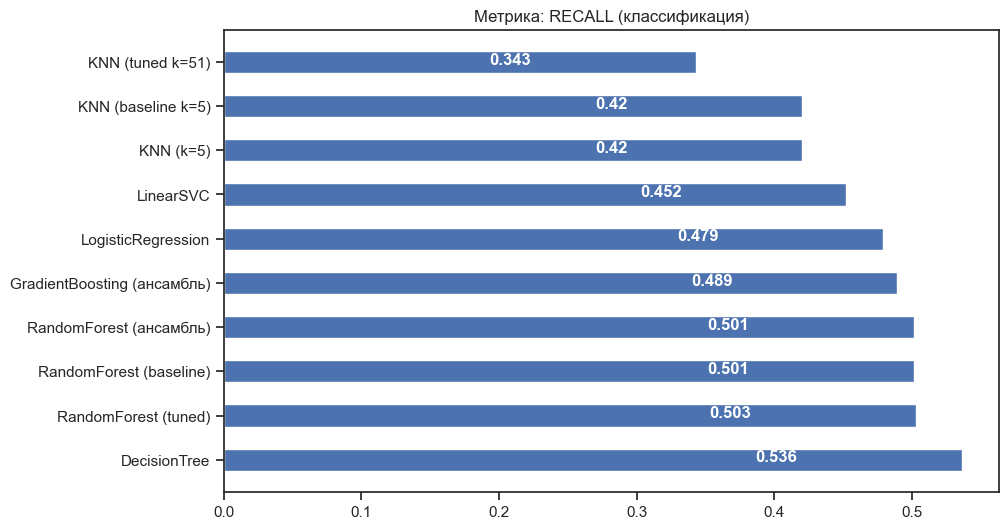

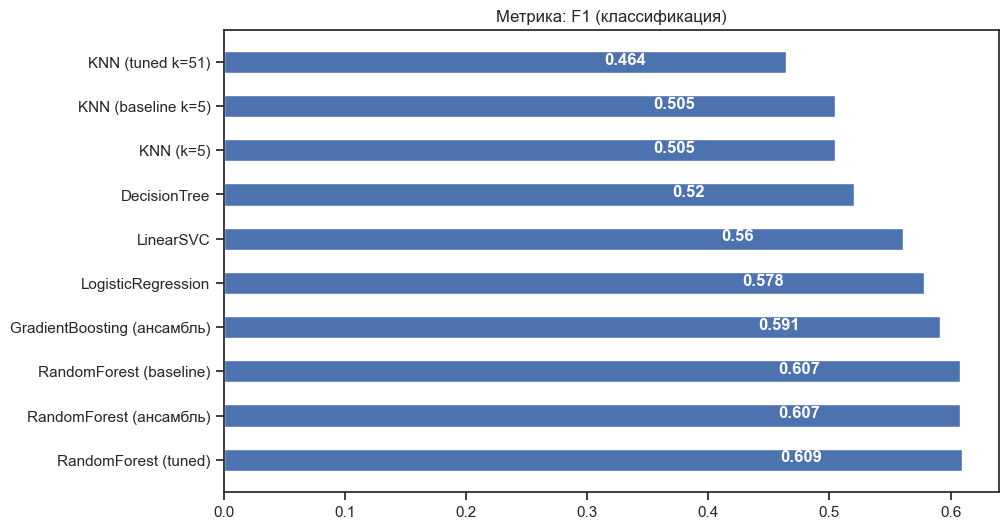

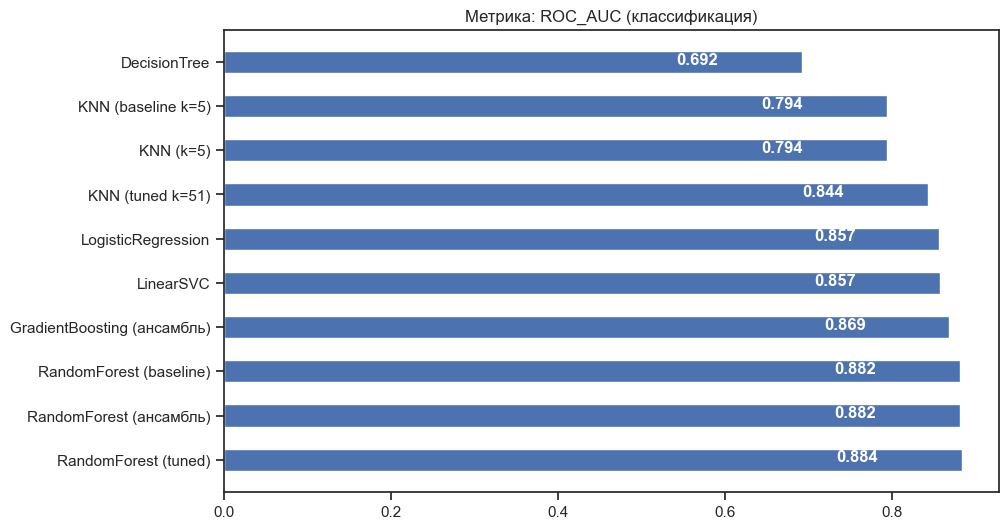

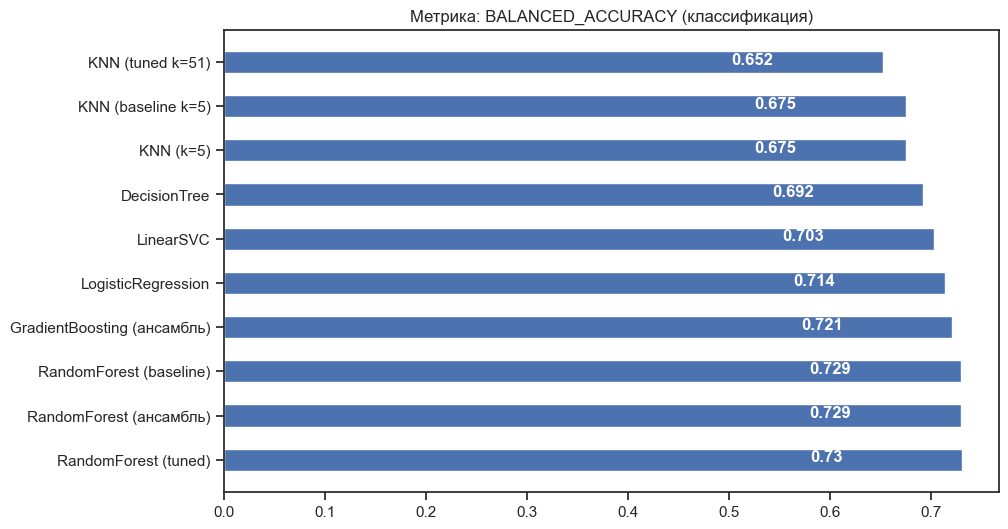

In [33]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'balanced_accuracy']

for metric in metrics_to_plot:
    clas_metrics_logger.plot(f'Метрика: {metric.upper()} (классификация)', 
                             metric, ascending=False, figsize=(10, 6))

### Сравнение качества моделей регрессии

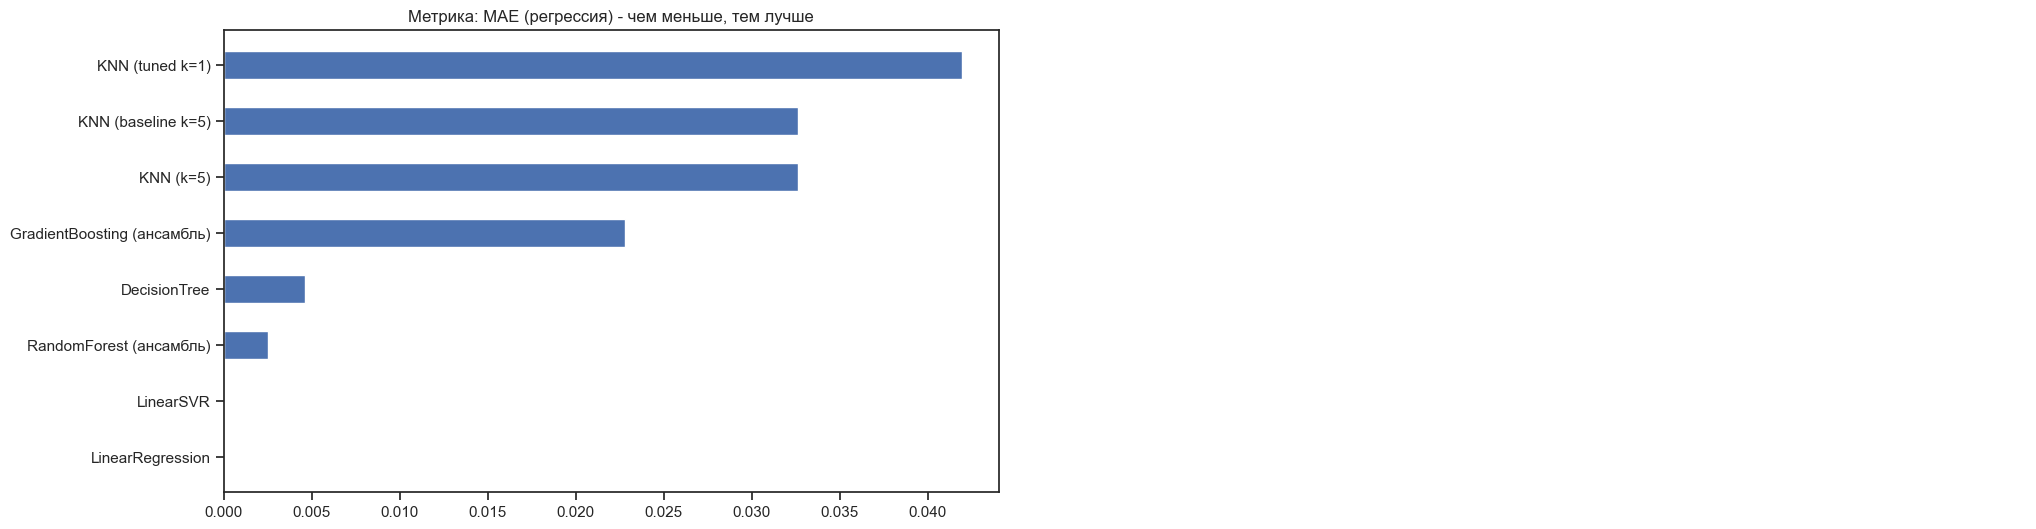

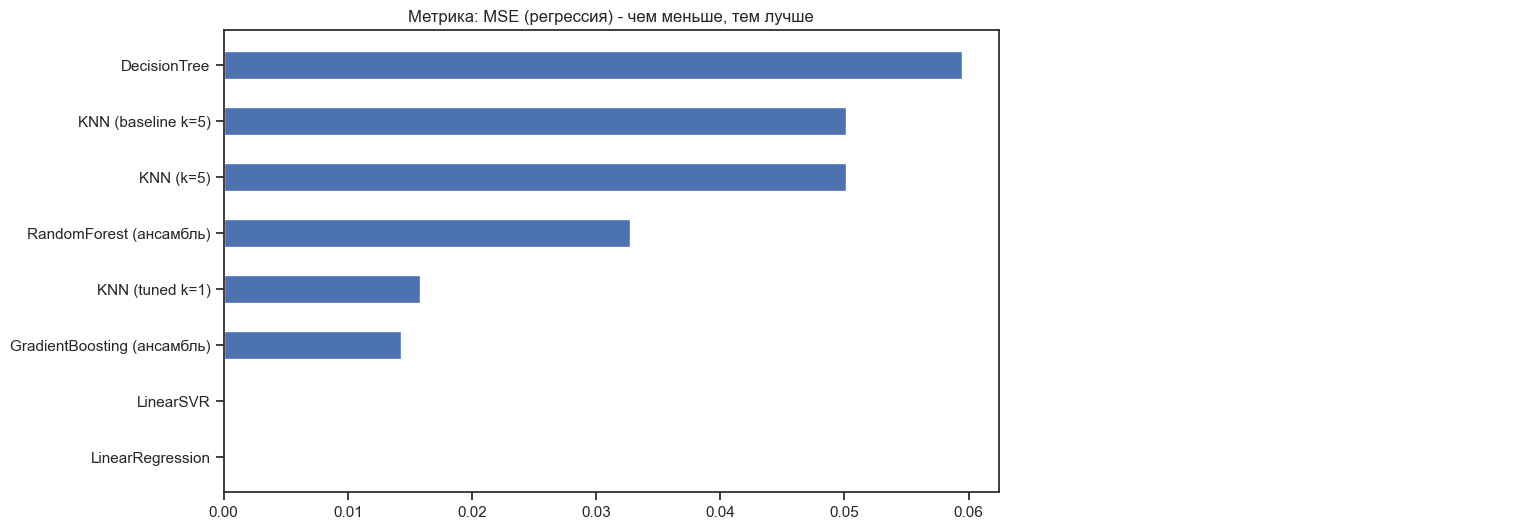

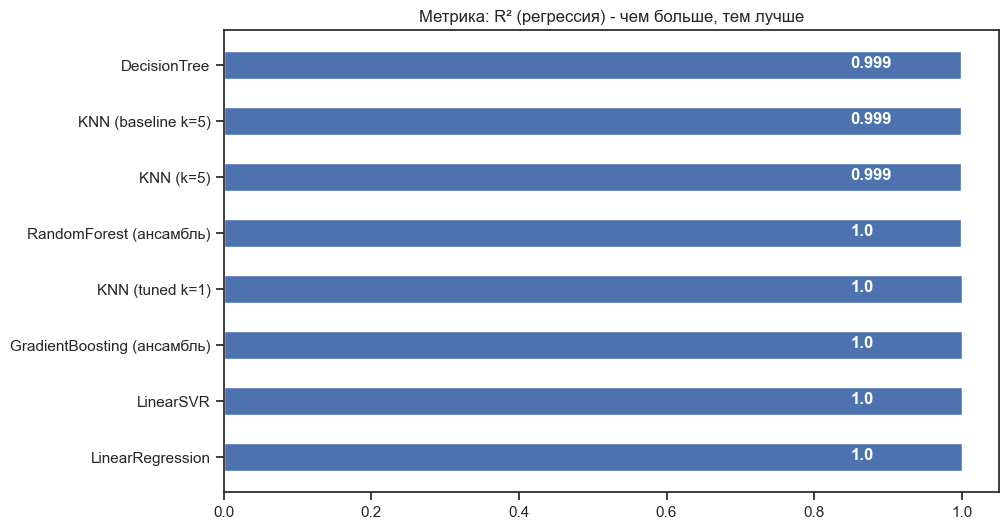

In [34]:
# Графики для метрик регрессии
regr_metrics_logger.plot('Метрика: MAE (регрессия) - чем меньше, тем лучше',
                         'MAE', ascending=True, figsize=(10, 6))
regr_metrics_logger.plot('Метрика: MSE (регрессия) - чем меньше, тем лучше',
                         'MSE', ascending=True, figsize=(10, 6))
regr_metrics_logger.plot('Метрика: R² (регрессия) - чем больше, тем лучше',
                         'R2', ascending=False, figsize=(10, 6))

## Сравнение результатов базовых и улучшенных моделей

### Выводы по задаче регрессии

#### Анализ базовых моделей:

1. **Линейная регрессия** и **LinearSVR** показали идеальные результаты (R² = 1.0000, MAE = 0.0000), что может свидетельствовать о:
   - Возможной утечке данных (data leakage) между обучающей и тестовой выборками
   - Линейной зависимости целевого признака от предикторов
   - Необходимости дополнительной проверки корректности разделения выборок

2. **GradientBoosting** показал отличный результат (R² = 0.9998, MAE = 0.0228), что делает его лучшей ансамблевой моделью.

3. **RandomForest** также продемонстрировал высокое качество (R² = 0.9995, MAE = 0.0025).

4. **KNN (k=5)** показал R² = 0.9993, что сопоставимо с ансамблевыми методами.

5. **DecisionTree** ожидаемо показал результат ниже (R² = 0.9992), что связано со склонностью решающих деревьев к переобучению.

#### Влияние подбора гиперпараметров:

| Модель | R² (baseline) | R² (tuned) | Изменение |
|--------|---------------|------------|-----------|
| KNN (k=5 → k=1) | 0.9993 | 0.9998 | ↑ +0.0005 |

**Вывод:** Подбор гиперпараметров для KNN (изменение k с 5 на 1) улучшил качество модели. Оптимальное значение k=1 указывает на высокую локальную вариативность данных — каждый объект лучше всего предсказывается по самому похожему соседу.

---

### Выводы по задаче классификации

#### Анализ базовых моделей:

1. **Лучшая базовая модель:** RandomForest (Accuracy = 0.8546, ROC-AUC = 0.8818)
2. **Вторая по качеству:** GradientBoosting (Accuracy = 0.8484, ROC-AUC = 0.8693)
3. **Линейные модели:** LogisticRegression и LinearSVC показали близкие результаты (ROC-AUC ≈ 0.857)
4. **Худшая модель:** DecisionTree (ROC-AUC = 0.6921) — склонность к переобучению

#### Влияние подбора гиперпараметров:

| Модель | ROC-AUC (baseline) | ROC-AUC (tuned) | Изменение |
|--------|-------------------|-----------------|-----------|
| KNN (k=5 → k=51) | 0.7944 | 0.8435 | ↑ +0.0491 |
| RandomForest | 0.8818 | 0.8841 | ↑ +0.0023 |

**Ключевые наблюдения:**

1. **KNN:** Подбор гиперпараметров значительно улучшил качество (ROC-AUC вырос на 4.9%). Оптимальное значение k=51 (против baseline k=5) указывает на то, что для предсказания дождя требуется учитывать больше соседей, чтобы сгладить шум.

2. **RandomForest:** Улучшение незначительное (+0.0023), что говорит о том, что параметры по умолчанию уже близки к оптимальным для данной задачи.

3. **Проблема дисбаланса классов:** Значения Recall (0.34-0.50) значительно ниже Precision (0.63-0.77), что характерно для задач с несбалансированными классами (дождливых дней меньше, чем солнечных).

---

### Итоговые выводы

#### Лучшие модели для практического использования:

| Задача | Лучшая модель | Ключевая метрика | Значение |
|--------|---------------|------------------|----------|
| **Классификация** (прогноз дождя) | RandomForest (tuned) | ROC-AUC | 0.8841 |
| **Регрессия** (прогноз осадков) | GradientBoosting | R² | 0.9998 |

#### Рекомендации:

1. **Для предсказания факта дождя (RainTomorrow)** рекомендуется использовать **RandomForest** — он показывает лучший баланс между точностью и полнотой (F1 = 0.6092, ROC-AUC = 0.8841).

2. **Для предсказания количества осадков (Rainfall)** все модели показали очень высокое качество (R² > 0.999). GradientBoosting дает наилучший результат.

3. **Внимание к данным:** Идеальные результаты линейных моделей (R² = 1.0) требуют дополнительной проверки — возможно, имеет место утечка данных или целевой признак линейно выражается через другие признаки.

4. **Учет дисбаланса:** При использовании моделей классификации на практике следует учитывать, что recall (чувствительность к дождливым дням) составляет всего 0.34-0.50 — модель будет пропускать около половины дождливых дней.

